# Import example subject behavioral data

This notebook loads behavioral and stimulus-sequence `.mat` files for one example subject from `data/raw/`, ignoring the eyetracking files. It creates:

- `trials_df`: one row per behavioral trial
- `samples_df`: one row per sample within each trial
- `block_metadata_df`: one row per block with values that do not vary trial-to-trial

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

In [2]:
DATA_ROOT = Path("data/Murphy2021/raw")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("~/Documents/academic/data/Murphy2021/raw").expanduser()
EXAMPLE_SUBJECT = "DCB"
INCLUDE_TRAINING = False

subject_dir = DATA_ROOT / EXAMPLE_SUBJECT
subject_dir

PosixPath('data/Murphy2021/raw/DCB')

In [3]:
def load_mat(path):
    """Load a MATLAB .mat file and drop scipy's private metadata keys."""
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    return {key: value for key, value in mat.items() if not key.startswith("__")}


def matlab_value_to_python(value):
    """Convert MATLAB scalar/array/struct values into notebook-friendly Python objects."""
    if hasattr(value, "_fieldnames"):
        return {field: matlab_value_to_python(getattr(value, field)) for field in value._fieldnames}

    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return matlab_value_to_python(value.item())
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    return value


def flatten_dict(d, prefix=""):
    """Flatten nested metadata dictionaries into dot-separated columns."""
    rows = {}
    for key, value in d.items():
        name = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            rows.update(flatten_dict(value, name))
        else:
            rows[name] = value
    return rows


def parse_subject_session_block(path):
    """Read participant/session/block from file names like DCB_1_1.mat."""
    parts = path.stem.split("_")
    block = int(parts[-1])
    session_number = int(parts[-2])
    participant_id = "_".join(parts[:-2])
    return participant_id, session_number, block

In [4]:
session_dirs = sorted(
    path
    for path in subject_dir.iterdir()
    if path.is_dir() and (INCLUDE_TRAINING or path.name != "Training")
)

session_dirs

[PosixPath('data/Murphy2021/raw/DCB/S1'),
 PosixPath('data/Murphy2021/raw/DCB/S2'),
 PosixPath('data/Murphy2021/raw/DCB/S3')]

In [5]:
behav_columns = [
    "correct_response_dist",
    "response",
    "accuracy",
    "rt_from_go_cue",
    "trial_onset_ptb",
    "fixation_break_count",
]

trial_frames = []
sample_frames = []
block_metadata_rows = []

for session_dir in session_dirs:
    behaviour_dir = session_dir / "Behaviour"
    sample_seqs_dir = session_dir / "Sample_seqs"

    for behav_path in sorted(behaviour_dir.glob("*.mat")):
        sample_path = sample_seqs_dir / behav_path.name
        if not sample_path.exists():
            raise FileNotFoundError(f"Missing matching Sample_seqs file for {behav_path}")

        participant_id, session_number, block = parse_subject_session_block(behav_path)
        block_id = f"{participant_id}_S{session_number}_B{block}"

        behav_mat = load_mat(behav_path)
        sample_mat = load_mat(sample_path)

        behav = np.asarray(behav_mat["Behav"])
        t_refresh = np.asarray(behav_mat["tRefresh"])
        stim_in = np.asarray(sample_mat["stimIn"])
        distseqs = np.asarray(sample_mat["distseqs"])
        pswitch = np.asarray(sample_mat["pswitch"])

        if behav.ndim != 2 or behav.shape[1] != len(behav_columns):
            raise ValueError(f"Unexpected Behav shape in {behav_path}: {behav.shape}")

        n_planned_trials, n_samples = stim_in.shape
        n_trials = behav.shape[0]
        if n_trials > n_planned_trials:
            raise ValueError(
                f"More behavioral trials than stimulus rows for {block_id}: "
                f"Behav has {n_trials}, stimIn has {n_planned_trials}"
            )

        # Some blocks can be interrupted. Keep only rows with completed behavior
        # in the trial- and sample-level dataframes, and record the mismatch below.
        stim_in_completed = stim_in[:n_trials]
        distseqs_completed = distseqs[:n_trials]
        pswitch_completed = pswitch[:n_trials]
        t_refresh_completed = t_refresh[:n_trials]

        trial_df = pd.DataFrame(behav, columns=behav_columns)
        trial_df.insert(0, "trial", np.arange(1, n_trials + 1))
        trial_df.insert(0, "block", block)
        trial_df.insert(0, "session", session_number)
        trial_df.insert(0, "session_label", session_dir.name)
        trial_df.insert(0, "participant_id", participant_id)
        trial_df.insert(0, "subject_folder", subject_dir.name)
        trial_df.insert(0, "block_id", block_id)

        trial_df["n_presented_samples"] = np.sum(~np.isnan(stim_in_completed), axis=1)
        trial_df["final_sample_location"] = stim_in_completed[
            np.arange(n_trials), trial_df["n_presented_samples"].to_numpy() - 1
        ]
        trial_frames.append(trial_df)

        sample_df = pd.DataFrame(
            {
                "block_id": np.repeat(block_id, n_trials * n_samples),
                "subject_folder": np.repeat(subject_dir.name, n_trials * n_samples),
                "participant_id": np.repeat(participant_id, n_trials * n_samples),
                "session_label": np.repeat(session_dir.name, n_trials * n_samples),
                "session": np.repeat(session_number, n_trials * n_samples),
                "block": np.repeat(block, n_trials * n_samples),
                "trial": np.repeat(np.arange(1, n_trials + 1), n_samples),
                "sample": np.tile(np.arange(1, n_samples + 1), n_trials),
                "stim_location_deg": stim_in_completed.reshape(-1),
                "generative_dist": distseqs_completed.reshape(-1),
                "distribution_switch": pswitch_completed.reshape(-1),
                "sample_onset_from_trial_s": t_refresh_completed.reshape(-1),
            }
        )
        sample_frames.append(sample_df)

        metadata = {
            "block_id": block_id,
            "subject_folder": subject_dir.name,
            "participant_id": participant_id,
            "session_label": session_dir.name,
            "session": session_number,
            "block": block,
            "n_completed_trials": n_trials,
            "n_planned_trials": n_planned_trials,
            "has_incomplete_behaviour": n_trials != n_planned_trials,
            "n_samples": n_samples,
            "behaviour_file": str(behav_path),
            "sample_seqs_file": str(sample_path),
            "pshort": matlab_value_to_python(sample_mat["pshort"]),
        }
        for struct_name in ["gen", "timing", "stim"]:
            metadata.update(
                flatten_dict({struct_name: matlab_value_to_python(sample_mat[struct_name])})
            )
        block_metadata_rows.append(metadata)

trials_df = pd.concat(trial_frames, ignore_index=True)
samples_df = pd.concat(sample_frames, ignore_index=True)
block_metadata_df = pd.DataFrame(block_metadata_rows)

trials_df.shape, samples_df.shape, block_metadata_df.shape

((2005, 15), (24060, 12), (27, 58))

In [6]:
trials_df.head()

,block_id,subject_folder,participant_id,session_label,session,block,trial,correct_response_dist,response,accuracy,rt_from_go_cue,trial_onset_ptb,fixation_break_count,n_presented_samples,final_sample_location
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1.0,1.0,1.0,1.515773,1.497944e+09,0.0,8,19.0
1,DCB_S1_B1,DCB,DCB,S1,1,1,2,2.0,2.0,1.0,0.007256,1.497944e+09,0.0,12,4.0
2,DCB_S1_B1,DCB,DCB,S1,1,1,3,2.0,1.0,0.0,0.006124,1.497944e+09,0.0,12,11.0
3,DCB_S1_B1,DCB,DCB,S1,1,1,4,1.0,1.0,1.0,0.006226,1.497944e+09,0.0,12,29.0
4,DCB_S1_B1,DCB,DCB,S1,1,1,5,1.0,1.0,1.0,0.006103,1.497944e+09,0.0,4,47.0


In [7]:
samples_df.head(15)

,block_id,subject_folder,participant_id,session_label,session,block,trial,sample,stim_location_deg,generative_dist,distribution_switch,sample_onset_from_trial_s
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1,61.0,1.0,0.0,0.399993
1,DCB_S1_B1,DCB,DCB,S1,1,1,1,2,-38.0,1.0,0.0,0.799975
2,DCB_S1_B1,DCB,DCB,S1,1,1,1,3,81.0,1.0,0.0,1.199959
3,DCB_S1_B1,DCB,DCB,S1,1,1,1,4,7.0,1.0,0.0,1.599944
4,DCB_S1_B1,DCB,DCB,S1,1,1,1,5,-37.0,1.0,0.0,1.999933
5,DCB_S1_B1,DCB,DCB,S1,1,1,1,6,28.0,1.0,0.0,2.399927
6,DCB_S1_B1,DCB,DCB,S1,1,1,1,7,20.0,1.0,0.0,2.799911
7,DCB_S1_B1,DCB,DCB,S1,1,1,1,8,19.0,1.0,0.0,3.199891
8,DCB_S1_B1,DCB,DCB,S1,1,1,1,9,NaN,NaN,NaN,0.000000
9,DCB_S1_B1,DCB,DCB,S1,1,1,1,10,NaN,NaN,NaN,0.000000


In [8]:
samples_df.loc[samples_df['stim_location_deg']==-89.99,'stim_location_deg'] = -90.0
samples_df.loc[samples_df['stim_location_deg']==89.99,'stim_location_deg'] = 90.0

In [9]:
from scipy.stats import norm

mean_neg, mean_pos = -17, 17
std = 29

dist_neg = norm(loc=mean_neg, scale=std)
dist_pos = norm(loc=mean_pos, scale=std)

samples_df['LLR_pos'] = np.log(dist_pos.pdf(samples_df['stim_location_deg']) / dist_neg.pdf(samples_df['stim_location_deg']))
samples_df.head(15)

,block_id,subject_folder,participant_id,session_label,session,block,trial,sample,stim_location_deg,generative_dist,distribution_switch,sample_onset_from_trial_s,LLR_pos
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1,61.0,1.0,0.0,0.399993,2.466112
1,DCB_S1_B1,DCB,DCB,S1,1,1,1,2,-38.0,1.0,0.0,0.799975,-1.536266
2,DCB_S1_B1,DCB,DCB,S1,1,1,1,3,81.0,1.0,0.0,1.199959,3.274673
3,DCB_S1_B1,DCB,DCB,S1,1,1,1,4,7.0,1.0,0.0,1.599944,0.282996
4,DCB_S1_B1,DCB,DCB,S1,1,1,1,5,-37.0,1.0,0.0,1.999933,-1.495838
5,DCB_S1_B1,DCB,DCB,S1,1,1,1,6,28.0,1.0,0.0,2.399927,1.131986
6,DCB_S1_B1,DCB,DCB,S1,1,1,1,7,20.0,1.0,0.0,2.799911,0.808561
7,DCB_S1_B1,DCB,DCB,S1,1,1,1,8,19.0,1.0,0.0,3.199891,0.768133
8,DCB_S1_B1,DCB,DCB,S1,1,1,1,9,NaN,NaN,NaN,0.000000,NaN
9,DCB_S1_B1,DCB,DCB,S1,1,1,1,10,NaN,NaN,NaN,0.000000,NaN


In [10]:
block_metadata_df.head()

,block_id,subject_folder,participant_id,session_label,session,block,n_completed_trials,n_planned_trials,has_incomplete_behaviour,n_samples,...,stim.audio.device.NrOutputChannels,stim.audio.device.LowInputLatency,stim.audio.device.HighInputLatency,stim.audio.device.LowOutputLatency,stim.audio.device.HighOutputLatency,stim.audio.device.DefaultSampleRate,stim.audio.h,stim.audio.tonebuf,stim.audio.tonepos,stim.cbartex
0,DCB_S1_B1,DCB,DCB,S1,1,1,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
1,DCB_S1_B2,DCB,DCB,S1,1,2,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
2,DCB_S1_B3,DCB,DCB,S1,1,3,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
3,DCB_S1_B4,DCB,DCB,S1,1,4,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
4,DCB_S1_B5,DCB,DCB,S1,1,5,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13


In [11]:
trials_df.groupby(["session_label", "block"]).agg(
    n_trials=("trial", "size"),
    accuracy=("accuracy", "mean"),
    median_rt=("rt_from_go_cue", "median"),
    mean_presented_samples=("n_presented_samples", "mean"),
)

n_trials  accuracy  median_rt  mean_presented_samples
session_label block                                                       
S1            1            76  0.736842   0.006155               10.592105
              2            76  0.776316   0.006148               10.697368
              3            76  0.789474   0.006147               10.789474
              4            76  0.789474   0.006133               10.789474
              5            76  0.789474   0.006121               10.486842
              6            76  0.723684   0.006130               10.855263
              7            76  0.750000   0.006108               10.605263
              8            76  0.815789   0.006128               10.513158
              9            29  0.620690   0.006115               10.551724
S2            1            76  0.697368   0.006124               10.657895
              2            76  0.736842   0.006110               10.565789
              3            76  0.868421   0.006110               10.789474
              4            76  0.750000   0.006109               10.342105
              5            76  0.842105   0.006101               10.855263
              6            76  0.802632   0.006169               10.513158
              7            76  0.842105   0.006156               10.618421
              8            76  0.763158   0.006162               10.802632
              9            76  0.802632   0.006139               10.578947
S3            1            76  0.789474   0.006131               10.355263
              2            76  0.736842   0.006137               10.644737
              3            76  0.802632   0.006135               10.855263
              4            76  0.776316   0.006116               10.802632
              5            76  0.894737   0.006128               10.447368
              6            76  0.763158   0.006121               10.894737
              7            76  0.855263   0.006111               10.578947
              8            76  0.671053   0.006117               10.671053
              9            76  0.828947   0.006103               10.578947

In [12]:
block_metadata_df['n_completed_trials'].sum(), block_metadata_df['n_planned_trials'].sum()

(2005, 2052)

In [13]:
samples_arr_by_trial = (
    samples_df.sort_values("sample")
    .groupby(["session", "block", "trial"])["stim_location_deg"]
    .apply(lambda s: s.dropna().to_numpy())
)

trials_df["samples_arr"] = pd.MultiIndex.from_frame(
    trials_df[["session", "block", "trial"]]
).map(samples_arr_by_trial)

llr_arr_by_trial = (
    samples_df.sort_values("sample")
    .groupby(["session", "block", "trial"])["LLR_pos"]
    .apply(lambda s: s.dropna().to_numpy())
)

trials_df["LLR_arr"] = pd.MultiIndex.from_frame(
    trials_df[["session", "block", "trial"]]
).map(llr_arr_by_trial)

trials_df[["session", "block", "trial", "n_presented_samples", "samples_arr", "LLR_arr"]].head()

,session,block,trial,n_presented_samples,samples_arr,LLR_arr
0,1,1,1,8,"[61.0, -38.0, 81.0, 7.0, -37.0, 28.0, 20.0, 19.0]","[2.466111771700357, -1.5362663495838287, 3.274..."
1,1,1,2,12,"[-67.0, -35.0, -8.0, -34.0, -61.0, 6.0, -29.0,...","[-2.7086801426872777, -1.4149821640903688, -0...."
2,1,1,3,12,"[23.0, -25.0, -17.0, -25.0, 5.0, 1.0, -5.0, -2...","[0.9298454221165282, -1.0107015457788346, -0.6..."
3,1,1,4,12,"[-1.0, 67.0, -14.0, 0.0, 9.0, -10.0, 50.0, -32...","[-0.04042806183115348, 2.7086801426872777, -0...."
4,1,1,5,4,"[56.0, 5.0, 48.0, 47.0]","[2.2639714625445895, 0.202140309155767, 1.9405..."


In [14]:
def P_source_g_samples(samples_arr,mean_neg,mean_pos,std,h,P0,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(samples_arr)
    Lpos = P_sample_g_pos.pdf(samples_arr)
    L = np.stack((Lneg,Lpos),axis=1).T
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,-window_size:]
    for ii in range(L.shape[1]):
        P = L[:,ii][:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=0,keepdims=True)
    return P

In [15]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos"] = trials_df.apply(
    lambda row: float(
        P_source_g_samples(
            np.asarray(row["samples_arr"], dtype=float),
            mean_neg,
            mean_pos,
            std,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    ),
    axis=1,
)

trials_df["post_prob_1b_pos"] = trials_df.apply(
    lambda row: float(
        P_source_g_samples(
            np.asarray(row["samples_arr"], dtype=float),
            mean_neg,
            mean_pos,
            std,
            float(h_by_block.loc[row["block_id"]]),
            P0,
            window_size=1
        )[1, 0]
    ),
    axis=1,
)

trials_df[["block_id", "trial", "post_prob_pos", "post_prob_1b_pos"]].head()

,block_id,trial,post_prob_pos,post_prob_1b_pos
0,DCB_S1_B1,1,0.901507,0.683117
1,DCB_S1_B1,2,0.214954,0.540340
2,DCB_S1_B1,3,0.294163,0.609380
3,DCB_S1_B1,4,0.891987,0.763581
4,DCB_S1_B1,5,0.982251,0.869905


In [16]:
def psychometric_choice_probability(
    trials_df,
    variable,
    block_metadata_df=None,
    block_conditions=None,
    bins=None,
    n_bins=10,
    response_col="response",
    block_id_col="block_id",
    return_bins=False,
    return_counts=False,
):
    """Estimate P(choose positive source) as a function of a binned variable.

    Positive-source choices are expected to be encoded as response == 1.

    Parameters
    ----------
    trials_df : pandas.DataFrame
        Trial-level dataframe.
    variable : str or array-like
        Continuous trial-level variable to bin, e.g. "post_prob_pos". If an
        array is passed, it must have the same length as `trials_df`.
    block_metadata_df : pandas.DataFrame, optional
        Block-level metadata dataframe used when `block_conditions` is given.
    block_conditions : callable, pandas.Series, array-like, or dict, optional
        Conditions evaluated on `block_metadata_df`. A callable should take
        `block_metadata_df` and return a boolean mask. A dict maps column names
        to allowed values, iterables of allowed values, or callables evaluated
        on the column.
    bins : int or array-like, optional
        Number of equal-width bins or explicit bin edges. If omitted, `n_bins`
        equal-width bins spanning the observed values are used.
    n_bins : int, default 10
        Number of bins to use when `bins` is not provided.
    response_col : str, default "response"
        Trial-level response column, where positive-source choices are 1.
    block_id_col : str, default "block_id"
        Shared block identifier column in `trials_df` and `block_metadata_df`.
    return_bins : bool, default False
        If True, also return the bin edges actually used.
    return_counts : bool, default False
        If True, also return the number of trials in each bin.

    Returns
    -------
    bin_centers : numpy.ndarray
        Centers of the bins.
    choice_probabilities : numpy.ndarray
        Mean probability of response == 1 in each bin. Empty bins are NaN.
    counts : numpy.ndarray, optional
        Number of finite trials in each bin. Returned only when
        `return_counts=True`.
    bins : numpy.ndarray, optional
        Returned only when `return_bins=True`.
    """
    trial_data = trials_df.copy()

    if isinstance(variable, str):
        if variable not in trial_data.columns:
            raise KeyError(f"{variable!r} is not a column in trials_df")
        variable_values = trial_data[variable].to_numpy(dtype=float)
    else:
        variable_values = np.asarray(variable, dtype=float)
        if variable_values.shape[0] != len(trial_data):
            raise ValueError("array-like `variable` must have one value per row in trials_df")

    if response_col not in trial_data.columns:
        raise KeyError(f"{response_col!r} is not a column in trials_df")

    if block_conditions is not None:
        if block_metadata_df is None:
            raise ValueError("block_metadata_df is required when block_conditions is provided")
        if block_id_col not in trial_data.columns or block_id_col not in block_metadata_df.columns:
            raise KeyError(f"{block_id_col!r} must be present in trials_df and block_metadata_df")

        if callable(block_conditions):
            block_mask = block_conditions(block_metadata_df)
        elif isinstance(block_conditions, dict):
            block_mask = pd.Series(True, index=block_metadata_df.index)
            for column, condition in block_conditions.items():
                if column not in block_metadata_df.columns:
                    raise KeyError(f"{column!r} is not a column in block_metadata_df")
                values = block_metadata_df[column]
                if callable(condition):
                    condition_mask = condition(values)
                elif isinstance(condition, (list, tuple, set, np.ndarray, pd.Index)):
                    condition_mask = values.isin(condition)
                else:
                    condition_mask = values == condition
                block_mask &= pd.Series(condition_mask, index=block_metadata_df.index).astype(bool)
        else:
            block_mask = pd.Series(block_conditions, index=block_metadata_df.index).astype(bool)

        included_blocks = block_metadata_df.loc[block_mask, block_id_col]
        trial_mask = trial_data[block_id_col].isin(included_blocks)
        trial_data = trial_data.loc[trial_mask]
        variable_values = variable_values[trial_mask.to_numpy()]

    responses = trial_data[response_col].to_numpy(dtype=float)
    finite_mask = np.isfinite(variable_values) & np.isfinite(responses)
    variable_values = variable_values[finite_mask]
    responses = responses[finite_mask]

    if variable_values.size == 0:
        raise ValueError("No finite trials remain after applying filters")

    if bins is None:
        lo, hi = np.nanmin(variable_values), np.nanmax(variable_values)
        if lo == hi:
            half_width = 0.5 if lo == 0 else abs(lo) * 0.05
            lo, hi = lo - half_width, hi + half_width
        bins = np.linspace(lo, hi, n_bins + 1)
    elif np.isscalar(bins):
        lo, hi = np.nanmin(variable_values), np.nanmax(variable_values)
        if lo == hi:
            half_width = 0.5 if lo == 0 else abs(lo) * 0.05
            lo, hi = lo - half_width, hi + half_width
        bins = np.linspace(lo, hi, int(bins) + 1)
    else:
        bins = np.asarray(bins, dtype=float)

    if bins.ndim != 1 or bins.size < 2 or np.any(np.diff(bins) <= 0):
        raise ValueError("bins must be increasing bin edges or a positive integer")

    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_index = np.digitize(variable_values, bins, right=False) - 1
    bin_index[variable_values == bins[-1]] = len(bins) - 2

    choice_probabilities = np.full(len(bin_centers), np.nan)
    counts = np.zeros(len(bin_centers), dtype=int)
    for idx in range(len(bin_centers)):
        in_bin = bin_index == idx
        counts[idx] = np.count_nonzero(in_bin)
        if counts[idx] > 0:
            choice_probabilities[idx] = np.mean(responses[in_bin] == 1)

    output = (bin_centers, choice_probabilities)
    if return_counts:
        output = (*output, counts)

    if return_bins:
        return (*output, bins)
    return output

def psychometric_choice_probability_by_group(
    trials_df,
    variable,
    grouping_variable,
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=False,
):
    """Estimate P(choose positive source) for each discrete grouping value.

    Positive-source choices are expected to be encoded as response == 1. Unlike
    `psychometric_choice_probability`, this function does not bin `variable`.
    Instead, it groups trials by `grouping_variable` and checks that `variable`
    has a single value within each group.

    Parameters
    ----------
    trials_df : pandas.DataFrame
        Trial-level dataframe.
    variable : str or array-like
        Trial-level variable whose value should be constant within each group.
        If an array is passed, it must have the same length as `trials_df`.
    grouping_variable : str or array-like
        Discrete trial-level grouping variable. Choice probabilities are
        computed across all finite-response trials with the same grouping value.
        If an array is passed, it must have the same length as `trials_df`.
    block_metadata_df : pandas.DataFrame, optional
        Block-level metadata dataframe used when `block_conditions` is given.
    block_conditions : callable, pandas.Series, array-like, or dict, optional
        Conditions evaluated on `block_metadata_df`, with the same conventions
        as `psychometric_choice_probability`.
    response_col : str, default "response"
        Trial-level response column, where positive-source choices are 1.
    block_id_col : str, default "block_id"
        Shared block identifier column in `trials_df` and `block_metadata_df`.
    sort : bool, default True
        If True, return groups sorted by grouping value when possible.
    return_counts : bool, default False
        If True, also return the number of finite trials in each group.

    Returns
    -------
    choice_probabilities : numpy.ndarray
        Mean probability of response == 1 for each grouping value.
    variable_values : numpy.ndarray
        One value of `variable` for each grouping value.
    group_values : numpy.ndarray
        Unique values of `grouping_variable` corresponding to the returned
        choice probabilities.
    counts : numpy.ndarray, optional
        Number of finite trials in each group. Returned only when
        `return_counts=True`.
    """
    trial_data = trials_df.copy()

    if isinstance(variable, str):
        if variable not in trial_data.columns:
            raise KeyError(f"{variable!r} is not a column in trials_df")
        variable_values = trial_data[variable].to_numpy(dtype=float)
    else:
        variable_values = np.asarray(variable, dtype=float)
        if variable_values.shape[0] != len(trial_data):
            raise ValueError("array-like `variable` must have one value per row in trials_df")

    if isinstance(grouping_variable, str):
        if grouping_variable not in trial_data.columns:
            raise KeyError(f"{grouping_variable!r} is not a column in trials_df")
        group_values = trial_data[grouping_variable].to_numpy()
    else:
        group_values = np.asarray(grouping_variable)
        if group_values.shape[0] != len(trial_data):
            raise ValueError("array-like `grouping_variable` must have one value per row in trials_df")

    if response_col not in trial_data.columns:
        raise KeyError(f"{response_col!r} is not a column in trials_df")

    if block_conditions is not None:
        if block_metadata_df is None:
            raise ValueError("block_metadata_df is required when block_conditions is provided")
        if block_id_col not in trial_data.columns or block_id_col not in block_metadata_df.columns:
            raise KeyError(f"{block_id_col!r} must be present in trials_df and block_metadata_df")

        if callable(block_conditions):
            block_mask = block_conditions(block_metadata_df)
        elif isinstance(block_conditions, dict):
            block_mask = pd.Series(True, index=block_metadata_df.index)
            for column, condition in block_conditions.items():
                if column not in block_metadata_df.columns:
                    raise KeyError(f"{column!r} is not a column in block_metadata_df")
                values = block_metadata_df[column]
                if callable(condition):
                    condition_mask = condition(values)
                elif isinstance(condition, (list, tuple, set, np.ndarray, pd.Index)):
                    condition_mask = values.isin(condition)
                else:
                    condition_mask = values == condition
                block_mask &= pd.Series(condition_mask, index=block_metadata_df.index).astype(bool)
        else:
            block_mask = pd.Series(block_conditions, index=block_metadata_df.index).astype(bool)

        included_blocks = block_metadata_df.loc[block_mask, block_id_col]
        trial_mask = trial_data[block_id_col].isin(included_blocks)
        trial_data = trial_data.loc[trial_mask]
        variable_values = variable_values[trial_mask.to_numpy()]
        group_values = group_values[trial_mask.to_numpy()]

    responses = trial_data[response_col].to_numpy(dtype=float)
    finite_mask = np.isfinite(variable_values) & np.isfinite(responses) & pd.notna(group_values)
    grouped_data = pd.DataFrame(
        {
            "variable": variable_values[finite_mask],
            "group": group_values[finite_mask],
            "response": responses[finite_mask],
        }
    )

    if grouped_data.empty:
        raise ValueError("No finite trials remain after applying filters")

    grouped = grouped_data.groupby("group", sort=sort, dropna=True)
    group_order = []
    psychometric_values = []
    choice_probabilities = []
    counts = []
    for group_value, group_df in grouped:
        unique_variable_values = group_df["variable"].unique()
        if len(unique_variable_values) != 1:
            raise ValueError(
                f"`variable` must have exactly one value within each group; "
                f"group {group_value!r} has {len(unique_variable_values)} values"
            )
        group_order.append(group_value)
        psychometric_values.append(unique_variable_values[0])
        choice_probabilities.append(np.mean(group_df["response"].to_numpy() == 1))
        counts.append(len(group_df))

    output = (
        np.asarray(choice_probabilities, dtype=float),
        np.asarray(psychometric_values, dtype=float),
        np.asarray(group_order),
    )
    if return_counts:
        output = (*output, np.asarray(counts, dtype=int))
    return output

def psychometric_choice_probability_2d(
    trials_df,
    variables,
    block_metadata_df=None,
    block_conditions=None,
    bins=None,
    n_bins=10,
    response_col="response",
    block_id_col="block_id",
    return_flat=False,
    return_bins=False,
    return_counts=False,
):
    """Estimate P(choose positive source) in bins of two continuous variables.

    Positive-source choices are expected to be encoded as response == 1.

    Parameters
    ----------
    trials_df : pandas.DataFrame
        Trial-level dataframe.
    variables : sequence of two str or array-like
        Continuous trial-level variables to bin, e.g. ("post_prob_pos",
        "post_prob_1b_pos"). Array-like values must have one value per row in
        `trials_df`.
    block_metadata_df : pandas.DataFrame, optional
        Block-level metadata dataframe used when `block_conditions` is given.
    block_conditions : callable, pandas.Series, array-like, or dict, optional
        Conditions evaluated on `block_metadata_df`, with the same conventions
        as `psychometric_choice_probability`.
    bins : int, array-like, or sequence of two, optional
        Bin definition for the two variables. Use one integer for the same
        number of inferred bins along both dimensions, one array of edges for
        both dimensions, or a two-item sequence with separate definitions for
        each dimension. If omitted, `n_bins` inferred bins are used.
    n_bins : int or sequence of two int, default 10
        Number of bins to use when `bins` is not provided.
    response_col : str, default "response"
        Trial-level response column, where positive-source choices are 1.
    block_id_col : str, default "block_id"
        Shared block identifier column in `trials_df` and `block_metadata_df`.
    return_flat : bool, default False
        If False, return a grid of bin-center pairs and a grid of choice
        probabilities. If True, return unique one-dimensional bin codes and
        matching one-dimensional choice probabilities.
    return_bins : bool, default False
        If True, also return the x- and y-dimension bin edges actually used.
    return_counts : bool, default False
        If True, also return the number of trials in each bin.

    Returns
    -------
    bin_centers : numpy.ndarray
        If `return_flat=False`, array with shape (n_x_bins, n_y_bins, 2), where
        the last dimension stores the x and y bin centers.
    choice_probabilities : numpy.ndarray
        If `return_flat=False`, array with shape (n_x_bins, n_y_bins). Empty
        bins are NaN.
    counts : numpy.ndarray
        If `return_flat=False` and `return_counts=True`, array with shape
        (n_x_bins, n_y_bins) containing the number of finite trials in each
        bin.
    bin_codes : numpy.ndarray
        If `return_flat=True`, unique integer codes for each two-dimensional bin.
    choice_probabilities_flat : numpy.ndarray
        If `return_flat=True`, choice probabilities corresponding to `bin_codes`.
    counts_flat : numpy.ndarray
        If `return_flat=True` and `return_counts=True`, counts corresponding
        to `bin_codes`.
    x_bins, y_bins : numpy.ndarray, optional
        Returned only when `return_bins=True`.
    """
    if len(variables) != 2:
        raise ValueError("variables must contain exactly two entries")

    trial_data = trials_df.copy()
    variable_values = []
    for variable in variables:
        if isinstance(variable, str):
            if variable not in trial_data.columns:
                raise KeyError(f"{variable!r} is not a column in trials_df")
            values = trial_data[variable].to_numpy(dtype=float)
        else:
            values = np.asarray(variable, dtype=float)
            if values.shape[0] != len(trial_data):
                raise ValueError("array-like entries in `variables` must have one value per row in trials_df")
        variable_values.append(values)
    x_values, y_values = variable_values

    if response_col not in trial_data.columns:
        raise KeyError(f"{response_col!r} is not a column in trials_df")

    if block_conditions is not None:
        if block_metadata_df is None:
            raise ValueError("block_metadata_df is required when block_conditions is provided")
        if block_id_col not in trial_data.columns or block_id_col not in block_metadata_df.columns:
            raise KeyError(f"{block_id_col!r} must be present in trials_df and block_metadata_df")

        if callable(block_conditions):
            block_mask = block_conditions(block_metadata_df)
        elif isinstance(block_conditions, dict):
            block_mask = pd.Series(True, index=block_metadata_df.index)
            for column, condition in block_conditions.items():
                if column not in block_metadata_df.columns:
                    raise KeyError(f"{column!r} is not a column in block_metadata_df")
                values = block_metadata_df[column]
                if callable(condition):
                    condition_mask = condition(values)
                elif isinstance(condition, (list, tuple, set, np.ndarray, pd.Index)):
                    condition_mask = values.isin(condition)
                else:
                    condition_mask = values == condition
                block_mask &= pd.Series(condition_mask, index=block_metadata_df.index).astype(bool)
        else:
            block_mask = pd.Series(block_conditions, index=block_metadata_df.index).astype(bool)

        included_blocks = block_metadata_df.loc[block_mask, block_id_col]
        trial_mask = trial_data[block_id_col].isin(included_blocks)
        trial_data = trial_data.loc[trial_mask]
        x_values = x_values[trial_mask.to_numpy()]
        y_values = y_values[trial_mask.to_numpy()]

    responses = trial_data[response_col].to_numpy(dtype=float)
    finite_mask = np.isfinite(x_values) & np.isfinite(y_values) & np.isfinite(responses)
    x_values = x_values[finite_mask]
    y_values = y_values[finite_mask]
    responses = responses[finite_mask]

    if x_values.size == 0:
        raise ValueError("No finite trials remain after applying filters")

    def make_bins(values, bin_spec, default_n_bins):
        if bin_spec is None:
            n = int(default_n_bins)
            lo, hi = np.nanmin(values), np.nanmax(values)
            if lo == hi:
                half_width = 0.5 if lo == 0 else abs(lo) * 0.05
                lo, hi = lo - half_width, hi + half_width
            edges = np.linspace(lo, hi, n + 1)
        elif np.isscalar(bin_spec):
            lo, hi = np.nanmin(values), np.nanmax(values)
            if lo == hi:
                half_width = 0.5 if lo == 0 else abs(lo) * 0.05
                lo, hi = lo - half_width, hi + half_width
            edges = np.linspace(lo, hi, int(bin_spec) + 1)
        else:
            edges = np.asarray(bin_spec, dtype=float)
        if edges.ndim != 1 or edges.size < 2 or np.any(np.diff(edges) <= 0):
            raise ValueError("bins must be increasing bin edges or a positive integer")
        return edges

    if bins is None:
        x_bin_spec, y_bin_spec = None, None
    elif np.isscalar(bins):
        x_bin_spec, y_bin_spec = bins, bins
    elif isinstance(bins, tuple) and len(bins) == 2:
        x_bin_spec, y_bin_spec = bins
    else:
        x_bin_spec, y_bin_spec = bins, bins

    if np.isscalar(n_bins):
        x_n_bins, y_n_bins = int(n_bins), int(n_bins)
    else:
        if len(n_bins) != 2:
            raise ValueError("n_bins must be an integer or a two-item sequence")
        x_n_bins, y_n_bins = n_bins

    x_bins = make_bins(x_values, x_bin_spec, x_n_bins)
    y_bins = make_bins(y_values, y_bin_spec, y_n_bins)
    x_centers = (x_bins[:-1] + x_bins[1:]) / 2
    y_centers = (y_bins[:-1] + y_bins[1:]) / 2

    x_bin_index = np.digitize(x_values, x_bins, right=False) - 1
    y_bin_index = np.digitize(y_values, y_bins, right=False) - 1
    x_bin_index[x_values == x_bins[-1]] = len(x_bins) - 2
    y_bin_index[y_values == y_bins[-1]] = len(y_bins) - 2

    n_x_bins = len(x_centers)
    n_y_bins = len(y_centers)
    choice_probabilities = np.full((n_x_bins, n_y_bins), np.nan)
    counts = np.zeros((n_x_bins, n_y_bins), dtype=int)
    for x_idx in range(n_x_bins):
        for y_idx in range(n_y_bins):
            in_bin = (x_bin_index == x_idx) & (y_bin_index == y_idx)
            counts[x_idx, y_idx] = np.count_nonzero(in_bin)
            if counts[x_idx, y_idx] > 0:
                choice_probabilities[x_idx, y_idx] = np.mean(responses[in_bin] == 1)

    if return_flat:
        bin_codes = np.arange(n_x_bins * n_y_bins)
        output = (bin_codes, choice_probabilities.reshape(-1))
        if return_counts:
            output = (*output, counts.reshape(-1))
    else:
        x_center_grid, y_center_grid = np.meshgrid(x_centers, y_centers, indexing="ij")
        bin_centers = np.stack((x_center_grid, y_center_grid), axis=-1)
        output = (bin_centers, choice_probabilities)
        if return_counts:
            output = (*output, counts)

    if return_bins:
        return (*output, x_bins, y_bins)
    return output



In [17]:
from scipy.special import logit
trials_df['LPO_pos'] = logit(trials_df['post_prob_pos'])
trials_df['LPO_1b_pos'] = logit(trials_df['post_prob_1b_pos'])
trials_df[["block_id", "trial", "LPO_pos", "LPO_1b_pos"]].head()

,block_id,trial,LPO_pos,LPO_1b_pos
0,DCB_S1_B1,1,2.214082,0.768133
1,DCB_S1_B1,2,-1.295317,0.161712
2,DCB_S1_B1,3,-0.875250,0.444709
3,DCB_S1_B1,4,2.111204,1.172414
4,DCB_S1_B1,5,4.013534,1.900119


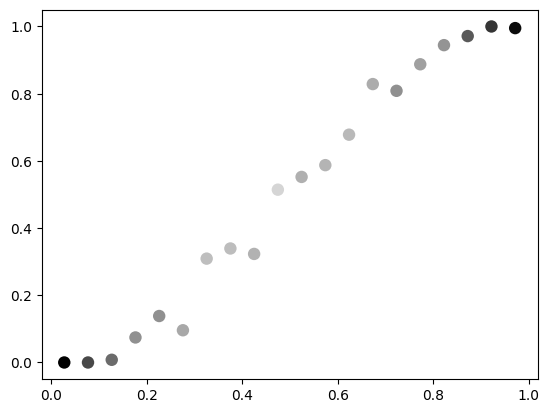

In [18]:
Pb_YgX, P_RgX, counts = psychometric_choice_probability(trials_df,trials_df['post_prob_pos'],n_bins=20,return_counts=True)
plt.scatter(Pb_YgX, P_RgX, c='k', s=80, alpha=counts / counts.max(), edgecolors='none')

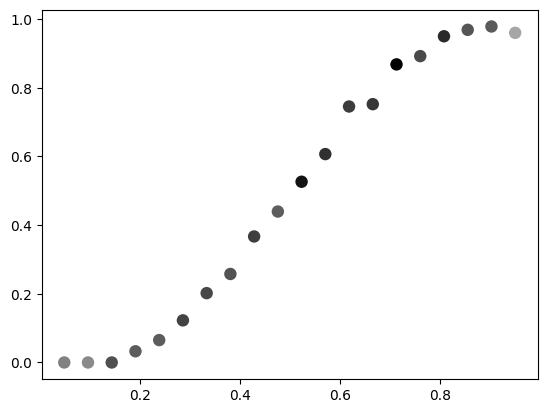

In [19]:
Pb_YgX_1b, P_RgX_1b, counts_1b = psychometric_choice_probability(trials_df,trials_df['post_prob_1b_pos'],n_bins=20,return_counts=True)
plt.scatter(Pb_YgX_1b, P_RgX_1b, c='k', s=80, alpha=counts_1b / counts_1b.max(), edgecolors='none')

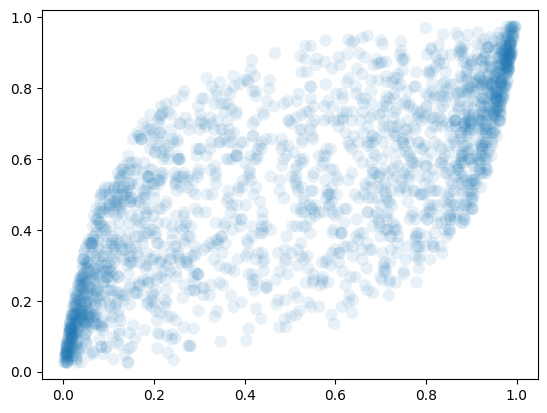

In [20]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_1b_pos'], s=80,alpha=0.1, edgecolor='none')

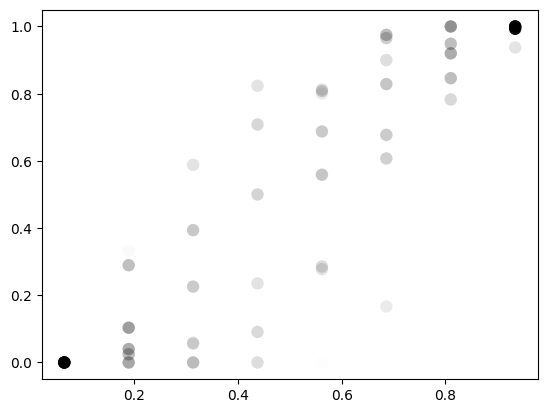

In [21]:
P_YgX_2d, P_RgX_2d, counts_2d = psychometric_choice_probability_2d(trials_df, ("post_prob_pos", "post_prob_1b_pos"), n_bins=8, return_counts=True)
plt.scatter(P_YgX_2d[:,:,0], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

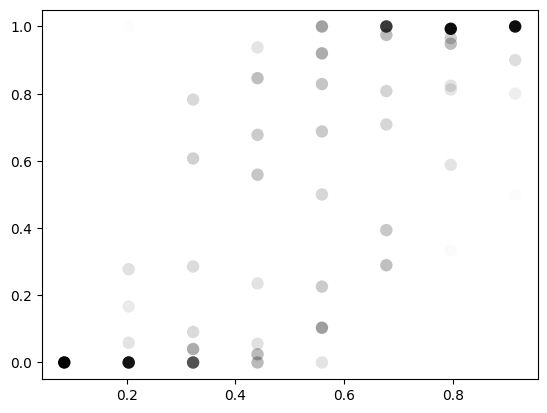

In [22]:
plt.scatter(P_YgX_2d[:,:,1], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

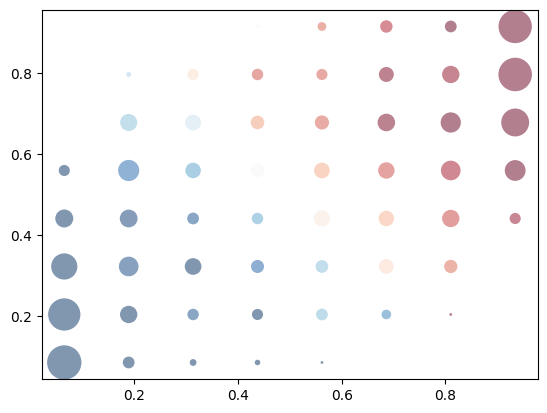

In [23]:
plt.scatter(P_YgX_2d[:,:,0].flatten(),P_YgX_2d[:,:,1].flatten(),s=counts_2d.flatten()*4,alpha=0.5, edgecolor='none', c=P_RgX_2d.flatten(), cmap='RdBu_r', vmin=0, vmax=1)

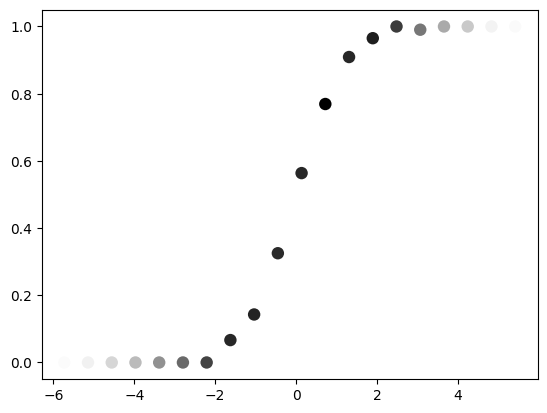

In [24]:
Lb_YgX, P_RgX, counts = psychometric_choice_probability(trials_df,trials_df['LPO_pos'],n_bins=20,return_counts=True)
plt.scatter(Lb_YgX, P_RgX, c='k', s=80, alpha=counts / counts.max(), edgecolors='none')

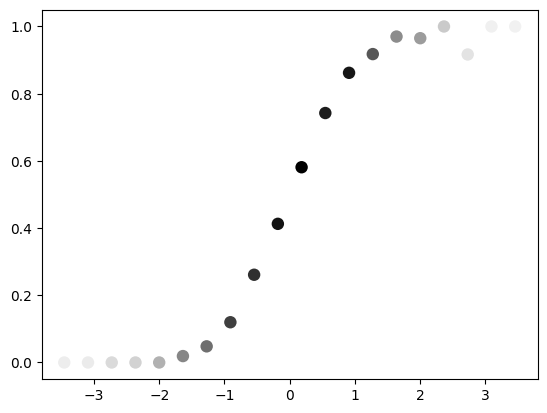

In [25]:
Lb_YgX_1b, P_RgX_1b, counts_1b = psychometric_choice_probability(trials_df,trials_df['LPO_1b_pos'],n_bins=20,return_counts=True)
plt.scatter(Lb_YgX_1b, P_RgX_1b, c='k', s=80, alpha=counts_1b / counts_1b.max(), edgecolors='none')

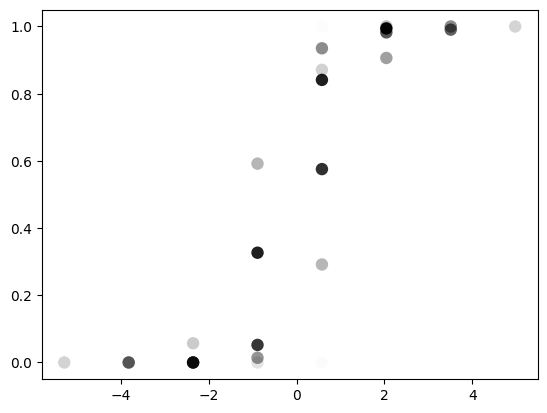

In [26]:
L_YgX_2d, P_RgX_2d, counts_2d = psychometric_choice_probability_2d(trials_df, ("LPO_pos", "LPO_1b_pos"), n_bins=8, return_counts=True)
plt.scatter(L_YgX_2d[:,:,0], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

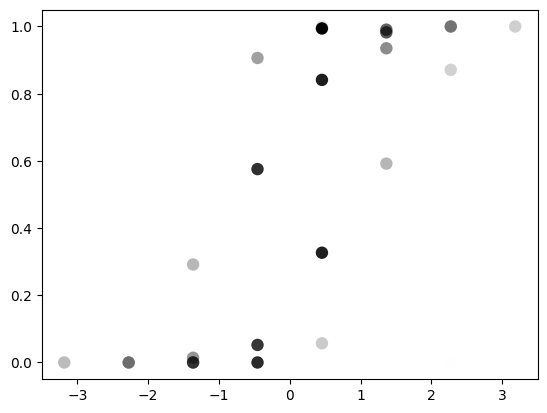

In [27]:
plt.scatter(L_YgX_2d[:,:,1], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

In [28]:
L_YgX_2d, P_RgX_2d, bins_opt, bins_1b = psychometric_choice_probability_2d(trials_df, ("LPO_pos", "LPO_1b_pos"), n_bins=10, return_bins=True)

In [29]:
P_YgX_2d, P_RgX_2d, counts_2d = psychometric_choice_probability_2d(trials_df, ("post_prob_pos", "post_prob_1b_pos"), bins=(np.exp(bins_opt) / (np.exp(bins_opt) + 1), np.exp(bins_1b) / (np.exp(bins_1b) + 1)), return_counts=True)

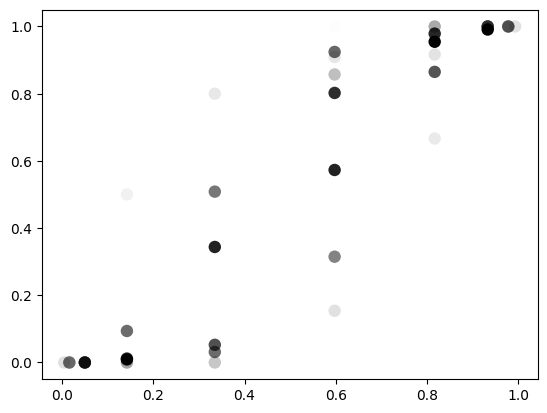

In [30]:
plt.scatter(P_YgX_2d[:,:,0], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

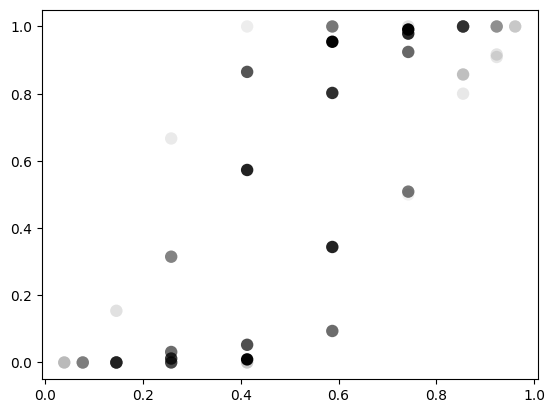

In [31]:
plt.scatter(P_YgX_2d[:,:,1], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

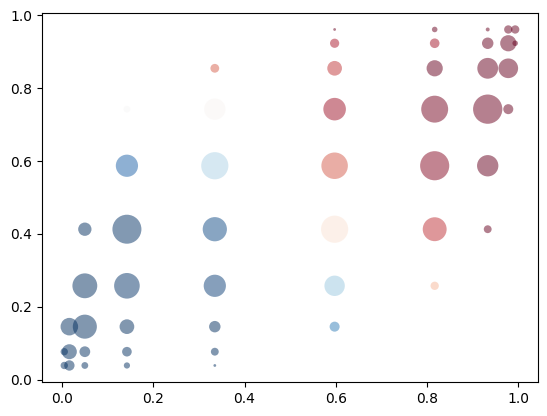

In [32]:
plt.scatter(P_YgX_2d[:,:,0],P_YgX_2d[:,:,1],s=counts_2d*4,alpha=0.5, edgecolor='none', c=P_RgX_2d, cmap='RdBu_r', vmin=0, vmax=1)

In [33]:
def partition_normal(norm_obj, cuts):
    cuts = np.asarray(cuts)
    cdf_values = norm_obj.cdf(cuts)
    probabilities = np.diff(np.concatenate(([0], cdf_values, [1])))
    return probabilities

def compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, cuts):
    p_XgY0 = partition_normal(dist_neg, cuts)
    p_XgY1 = partition_normal(dist_pos, cuts)
    p_XgY = np.stack((p_XgY0, p_XgY1), axis=1)
    p_XY = p_Y * p_XgY
    p_X = p_XY.sum(axis=1,keepdims=True)
    Ixy = np.nansum(p_XY * np.log(p_XY/(p_X*p_Y)))
    return Ixy

In [34]:
def obj_function(cut, dist_neg, dist_pos, p_Y):
    return -compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, [-cut,0,cut])

norm_neg = norm(loc=mean_neg, scale=std)
norm_pos = norm(loc=mean_pos, scale=std)

from scipy.optimize import minimize_scalar
result = minimize_scalar(obj_function, args=(norm_neg, norm_pos, np.array([[0.5, 0.5]])), bounds=(0, 89), method='bounded')
cut = result.x
cuts = [-cut, 0, cut]
cuts

[-26.861508114762714, 0, 26.861508114762714]

In [35]:
def map_to_partition(sample_arr, cuts):
    sample_arr = np.asarray(sample_arr)
    cuts = np.asarray(cuts)
    bin_edges = np.concatenate(([-np.inf], cuts, [np.inf]))
    bin_indices = np.digitize(sample_arr, bin_edges) - 1
    return bin_indices

def P_source_g_partsamples(partsamples_arr,mean_neg,mean_pos,std,cuts,h,P0,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    Lneg = P_partsamples_g_neg[partsamples_arr]
    Lpos = P_partsamples_g_pos[partsamples_arr]
    L = np.stack((Lneg,Lpos),axis=1).T
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,-window_size:]
    for ii in range(L.shape[1]):
        P = L[:,ii][:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=0,keepdims=True)
    return P

def P_partsamples_g_source_parallel(partsample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    Lneg = P_partsamples_g_neg[partsample_arrs]
    Lpos = P_partsamples_g_pos[partsample_arrs]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    H = H.T # because we are going "backwards" from source to samples
    P = np.ones((L.shape[0],2,1))
    if window_size is not None:
        L = L[:,:,-window_size:]
    # for ii in range(L.shape[2]-1,0,-1):
    #     P = H @ (L[:,:,ii][:,:,np.newaxis] * P)
    for ii in range(1,L.shape[2]):
        P = H @ (L[:,:,ii-1][:,:,np.newaxis] * P)
    P = L[:,:,L.shape[2]-1][:,:,np.newaxis] * P
    return P.squeeze()

def P_source_g_partsamples_parallel(sample_arrs,mean_neg,mean_pos,std,cuts,h,P0,window_size=None):
    p_XgY = P_partsamples_g_source_parallel(sample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=window_size)
    p_XY = p_XgY * P0.T
    p_YgX = p_XY / p_XY.sum(axis=1,keepdims=True)
    return p_YgX.squeeze()

In [36]:
from itertools import permutations

def list_permutations_1d(arr):
    """Return all permutations of a 1D array-like as a 2D NumPy array."""
    arr = np.asarray(arr)
    if arr.ndim != 1:
        raise ValueError("Input must be 1D.")


    return np.array(list(permutations(arr.tolist())), dtype=arr.dtype)

np.unique(list_permutations_1d([1,1,1,1,2]), axis=0).shape

(5, 5)

In [37]:
def P_source_g_partsamplesset(partsamples_arr,mean_neg,mean_pos,std,cuts,h,p_Y,window_size=None):
    partsample_arrs = np.unique(list_permutations_1d(partsamples_arr), axis=0)
    p_XgY_all = P_partsamples_g_source_parallel(partsample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=window_size)
    p_XY_all = p_XgY_all * p_Y
    p_XY = np.sum(p_XY_all, axis=0,keepdims=True)
    p_YgX = p_XY / p_XY.sum(axis=1,keepdims=True)
    return p_YgX

In [38]:
mapper = globals().get("map_to_paritition", map_to_partition)

trials_df["partsamples_arr"] = trials_df["samples_arr"].apply(
    lambda arr: mapper(np.asarray(arr), cuts)
)

trials_df[["samples_arr", "partsamples_arr"]].head()

,samples_arr,partsamples_arr
0,"[61.0, -38.0, 81.0, 7.0, -37.0, 28.0, 20.0, 19.0]","[3, 0, 3, 2, 0, 3, 2, 2]"
1,"[-67.0, -35.0, -8.0, -34.0, -61.0, 6.0, -29.0,...","[0, 0, 1, 0, 0, 2, 0, 1, 1, 2, 1, 2]"
2,"[23.0, -25.0, -17.0, -25.0, 5.0, 1.0, -5.0, -2...","[2, 1, 1, 1, 2, 2, 1, 0, 0, 3, 1, 2]"
3,"[-1.0, 67.0, -14.0, 0.0, 9.0, -10.0, 50.0, -32...","[1, 3, 1, 2, 2, 1, 3, 0, 2, 3, 1, 3]"
4,"[56.0, 5.0, 48.0, 47.0]","[3, 2, 3, 3]"


In [39]:
trials_df["partsamples_arr_5"] = trials_df["partsamples_arr"].apply(
    lambda x: np.asarray(x)[-5:] if isinstance(x, (list, np.ndarray)) and len(x) >= 5 else np.nan
)
trials_df[["partsamples_arr", "partsamples_arr_5"]].head()

,partsamples_arr,partsamples_arr_5
0,"[3, 0, 3, 2, 0, 3, 2, 2]","[2, 0, 3, 2, 2]"
1,"[0, 0, 1, 0, 0, 2, 0, 1, 1, 2, 1, 2]","[1, 1, 2, 1, 2]"
2,"[2, 1, 1, 1, 2, 2, 1, 0, 0, 3, 1, 2]","[0, 0, 3, 1, 2]"
3,"[1, 3, 1, 2, 2, 1, 3, 0, 2, 3, 1, 3]","[0, 2, 3, 1, 3]"
4,"[3, 2, 3, 3]",NaN


In [40]:
h = 0.08
p_Y = np.array([[0.5, 0.5]])
P_source_g_partsamplesset(trials_df['partsamples_arr_5'].iloc[0], mean_neg, mean_pos, std, cuts, h, p_Y, window_size=None)

array([[0.30104151, 0.69895849]])

In [41]:
P_source_g_partsamples(
    trials_df['partsamples_arr_5'].iloc[0],
    mean_neg,
    mean_pos,
    std,
    cuts,
    h,
    P0=np.array([[0.5], [0.5]]),
    window_size=None
)

array([[0.20144731],
       [0.79855269]])

In [42]:
P_source_g_partsamplesset(np.array([1,1,1,1,3]), mean_neg, mean_pos, std, cuts, h, p_Y, window_size=None)

array([[0.54770186, 0.45229814]])

In [43]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos_partsamples5"] = trials_df.apply(
    lambda row: float(
        P_source_g_partsamples(
            np.asarray(row["partsamples_arr_5"], dtype=int),
            mean_neg,
            mean_pos,
            std,
            cuts,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    if isinstance(row["partsamples_arr_5"], (list, np.ndarray)) else np.nan),
    axis=1,
)

trials_df[["post_prob_pos", "post_prob_pos_partsamples5"]].head()

,post_prob_pos,post_prob_pos_partsamples5
0,0.901507,0.798553
1,0.214954,0.476900
2,0.294163,0.471070
3,0.891987,0.882161
4,0.982251,NaN


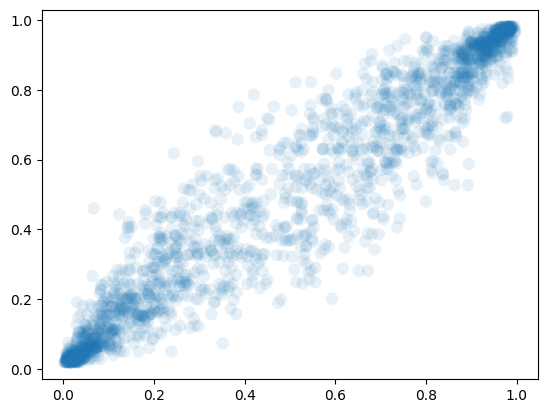

In [44]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_pos_partsamples5'], s=80,alpha=0.1, edgecolor='none')

In [48]:
trials_df["partsamples_arr_5_enc"] = trials_df["partsamples_arr_5"].apply(
    lambda arr: int(np.sum(10**np.arange(len(arr)-1,-1,-1) * np.asarray(arr))) if isinstance(arr, (list, np.ndarray)) else np.nan
)
trials_df[["partsamples_arr_5", "partsamples_arr_5_enc"]].head()

,partsamples_arr_5,partsamples_arr_5_enc
0,"[2, 0, 3, 2, 2]",20322.0
1,"[1, 1, 2, 1, 2]",11212.0
2,"[0, 0, 3, 1, 2]",312.0
3,"[0, 2, 3, 1, 3]",2313.0
4,NaN,NaN


In [49]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_partsamples5",
    "partsamples_arr_5_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)

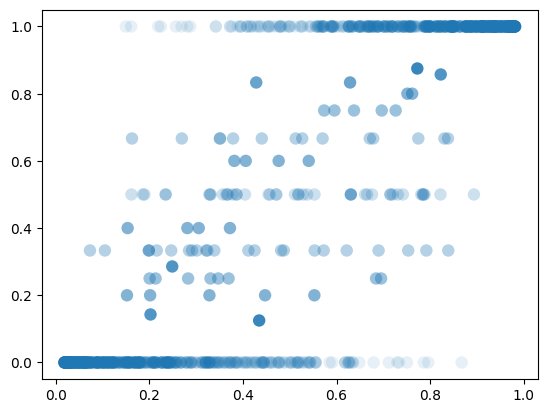

In [50]:
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [51]:
counts.max()

9

In [52]:
trials_df['LPO_pos_partsample5'] = logit(trials_df['post_prob_pos_partsamples5'])

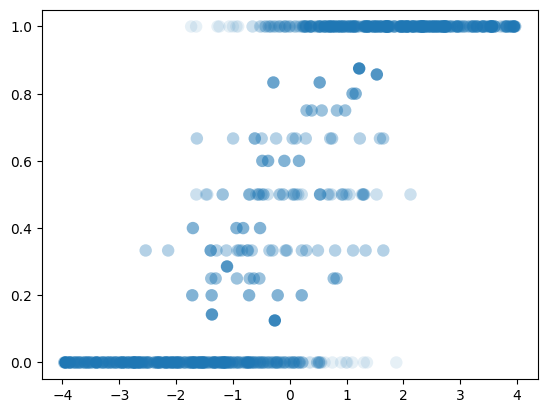

In [53]:
p_RgX, L_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "LPO_pos_partsample5",
    "partsamples_arr_5_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(L_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [54]:
counts.max()

9

In [55]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
# P0 = np.array([[0.5], [0.5]])
p_Y = np.array([[0.5, 0.5]])

trials_df["post_prob_pos_partsamples5set"] = trials_df.apply(
    lambda row: float(
        P_source_g_partsamplesset(
            np.asarray(row["partsamples_arr_5"], dtype=int),
            mean_neg,
            mean_pos,
            std,
            cuts,
            float(h_by_block.loc[row["block_id"]]),
            p_Y,
        )[0,1]
    if isinstance(row["partsamples_arr_5"], (list, np.ndarray)) else np.nan),
    axis=1,
)

trials_df[["post_prob_pos", "post_prob_pos_partsamples5", "post_prob_pos_partsamples5set"]].head()

,post_prob_pos,post_prob_pos_partsamples5,post_prob_pos_partsamples5set
0,0.901507,0.798553,0.698958
1,0.214954,0.476900,0.413055
2,0.294163,0.471070,0.300854
3,0.891987,0.882161,0.699146
4,0.982251,NaN,NaN


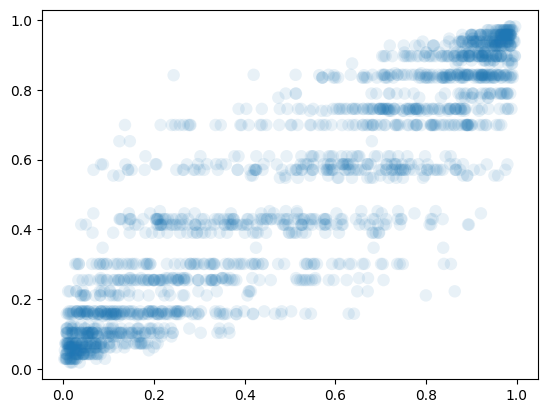

In [56]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_pos_partsamples5set'], s=80,alpha=0.1, edgecolor='none')

In [57]:
trials_df["partsamplesset_arr_5_enc"] = trials_df["partsamples_arr_5"].apply(
    lambda arr: np.sum(10**np.array(arr)) if isinstance(arr, (list, np.ndarray)) else np.nan
)
trials_df[["partsamples_arr_5", "partsamplesset_arr_5_enc"]].head()

,partsamples_arr_5,partsamplesset_arr_5_enc
0,"[2, 0, 3, 2, 2]",1301.0
1,"[1, 1, 2, 1, 2]",230.0
2,"[0, 0, 3, 1, 2]",1112.0
3,"[0, 2, 3, 1, 3]",2111.0
4,NaN,NaN


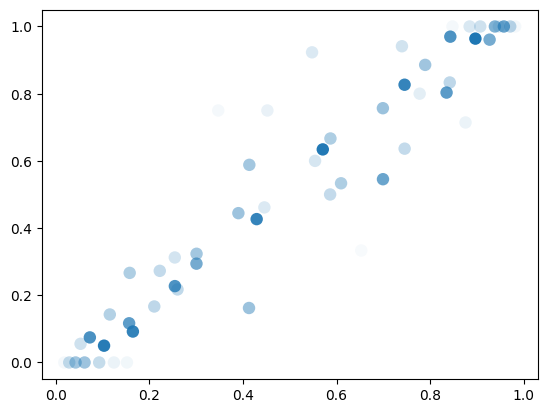

In [58]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_partsamples5set",
    "partsamplesset_arr_5_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [65]:
trials_df["partsamples_arr_4"] = trials_df["partsamples_arr"].apply(
    lambda x: np.asarray(x)[-4:] if isinstance(x, (list, np.ndarray)) and len(x) >= 4 else np.nan
)
trials_df[["partsamples_arr", "partsamples_arr_4"]].head()

,partsamples_arr,partsamples_arr_4
0,"[3, 0, 3, 2, 0, 3, 2, 2]","[0, 3, 2, 2]"
1,"[0, 0, 1, 0, 0, 2, 0, 1, 1, 2, 1, 2]","[1, 2, 1, 2]"
2,"[2, 1, 1, 1, 2, 2, 1, 0, 0, 3, 1, 2]","[0, 3, 1, 2]"
3,"[1, 3, 1, 2, 2, 1, 3, 0, 2, 3, 1, 3]","[2, 3, 1, 3]"
4,"[3, 2, 3, 3]","[3, 2, 3, 3]"


In [47]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos_partsamples4"] = trials_df.apply(
    lambda row: float(
        P_source_g_partsamples(
            np.asarray(row["partsamples_arr_4"], dtype=int),
            mean_neg,
            mean_pos,
            std,
            cuts,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    if isinstance(row["partsamples_arr_4"], (list, np.ndarray)) else np.nan),
    axis=1,
)

trials_df[["post_prob_pos", "post_prob_pos_partsamples4"]].head()

,post_prob_pos,post_prob_pos_partsamples4
0,0.901507,0.766344
1,0.214954,0.535324
2,0.294163,0.586681
3,0.891987,0.932227
4,0.982251,0.977539


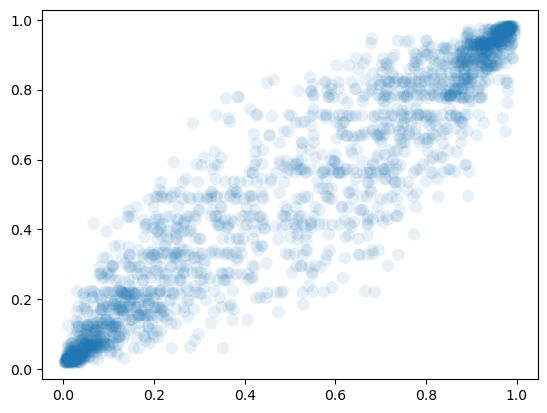

In [74]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_pos_partsamples4'], s=80,alpha=0.1, edgecolor='none')

In [49]:
trials_df["partsamples_arr_4_enc"] = trials_df["partsamples_arr_4"].apply(
    lambda arr: int(np.sum(10**np.arange(len(arr)-1,-1,-1) * np.asarray(arr))) if isinstance(arr, (list, np.ndarray)) else np.nan
)
trials_df[["partsamples_arr_4", "partsamples_arr_4_enc"]].head()

,partsamples_arr_4,partsamples_arr_4_enc
0,"[0, 3, 2, 2]",322.0
1,"[1, 2, 1, 2]",1212.0
2,"[0, 3, 1, 2]",312.0
3,"[2, 3, 1, 3]",2313.0
4,"[3, 2, 3, 3]",3233.0


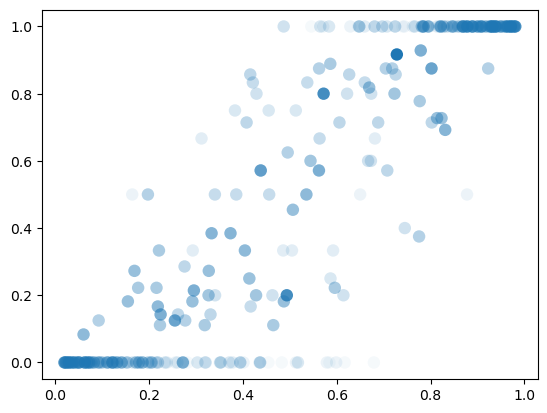

In [144]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_partsamples4",
    "partsamples_arr_4_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [145]:
counts.max()

24

In [54]:
trials_df['LPO_pos_partsample4'] = logit(trials_df['post_prob_pos_partsamples4'])

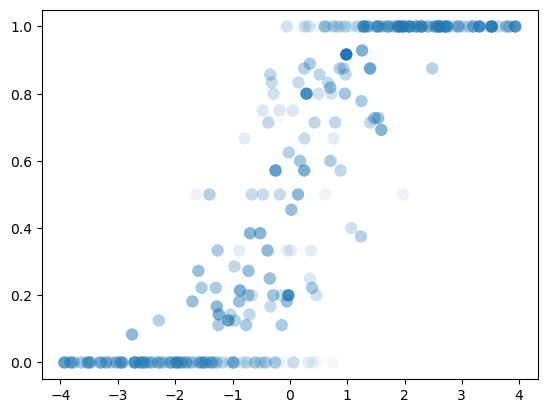

In [55]:
p_RgX, L_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "LPO_pos_partsample4",
    "partsamples_arr_4_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(L_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

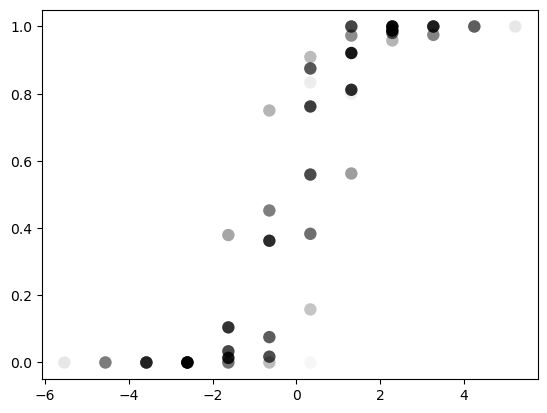

In [61]:
L_YgX_2d, P_RgX_2d, counts_2d = psychometric_choice_probability_2d(trials_df, ("LPO_pos", "LPO_1b_pos"), n_bins=12, return_counts=True)
plt.scatter(L_YgX_2d[:,:,0], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

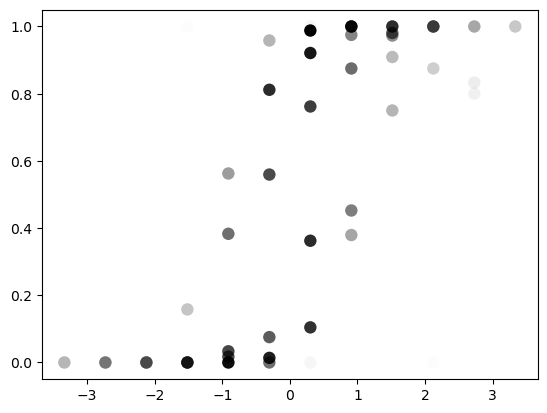

In [62]:
plt.scatter(L_YgX_2d[:,:,1], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

In [131]:
L_YgX_2d, P_RgX_2d, bins1, bins2 = psychometric_choice_probability_2d(trials_df, ("LPO_pos", "LPO_1b_pos"), n_bins=15, return_bins=True)

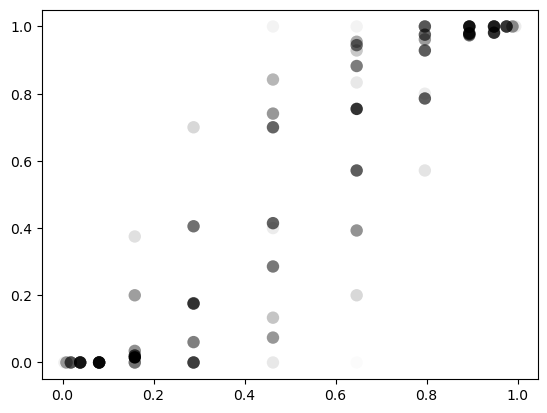

In [132]:
P_YgX_2d, P_RgX_2d, counts_2d = psychometric_choice_probability_2d(trials_df, ("post_prob_pos", "post_prob_1b_pos"), bins=(np.exp(bins1) / (np.exp(bins1) + 1), np.exp(bins2) / (np.exp(bins2) + 1)), return_counts=True)
plt.scatter(P_YgX_2d[:,:,0], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

(array([[15.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [14.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [12.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [11.,  1.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.],
        [ 8.,  2.,  2.,  0.,  1.,  1.,  0.,  1.,  0.,  0.],
        [ 8.,  1.,  0.,  0.,  4.,  1.,  1.,  0.,  0.,  0.],
        [ 8.,  1.,  0.,  0.,  0.,  1.,  4.,  1.,  0.,  0.],
        [ 8.,  0.,  0.,  1.,  0.,  0.,  4.,  0.,  1.,  1.],
        [ 8.,  0.,  1.,  1.,  0.,  2.,  2.,  1.,  0.,  0.],
        [ 8.,  1.,  0.,  0.,  1.,  3.,  0.,  0.,  2.,  0.],
        [ 8.,  1.,  1.,  3.,  0.,  1.,  0.,  1.,  0.,  0.],
        [10.,  0.,  4.,  0.,  0.,  1.,  0.,  0.,  0.,  0.],
        [11.,  2.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [15.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [14.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]),
 array([ 0. ,  6.6, 13.2, 19.8, 26.4, 33. , 39.6, 46.2, 52.8, 59.4, 66. ]),
 <a list of 15 BarCont

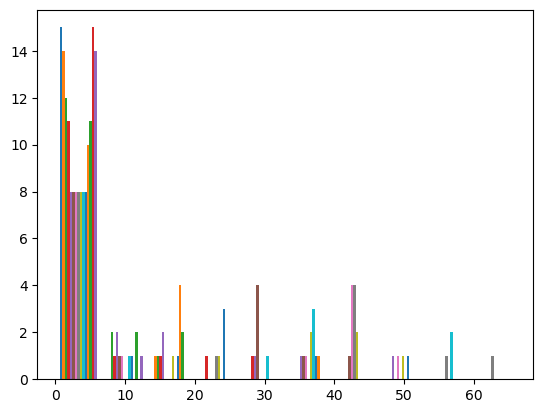

In [133]:
plt.hist(counts_2d)

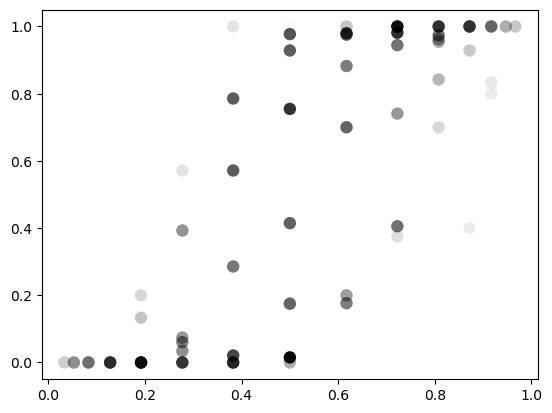

In [134]:
plt.scatter(P_YgX_2d[:,:,1], P_RgX_2d, c='k', s=80, alpha=counts_2d / counts_2d.max(), edgecolors='none')

In [68]:
trials_df["partsamples_arr_3"] = trials_df["partsamples_arr"].apply(
    lambda x: np.asarray(x)[-3:] if isinstance(x, (list, np.ndarray)) and len(x) >= 3 else np.nan
)
trials_df[["partsamples_arr", "partsamples_arr_3"]].head()

,partsamples_arr,partsamples_arr_3
0,"[3, 0, 3, 2, 0, 3, 2, 2]","[3, 2, 2]"
1,"[0, 0, 1, 0, 0, 2, 0, 1, 1, 2, 1, 2]","[2, 1, 2]"
2,"[2, 1, 1, 1, 2, 2, 1, 0, 0, 3, 1, 2]","[3, 1, 2]"
3,"[1, 3, 1, 2, 2, 1, 3, 0, 2, 3, 1, 3]","[3, 1, 3]"
4,"[3, 2, 3, 3]","[2, 3, 3]"


In [ ]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos_partsamples3"] = trials_df.apply(
    lambda row: float(
        P_source_g_partsamples(
            np.asarray(row["partsamples_arr_3"], dtype=int),
            mean_neg,
            mean_pos,
            std,
            cuts,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    if isinstance(row["partsamples_arr_3"], (list, np.ndarray)) else np.nan),
    axis=1,
)

trials_df[["post_prob_pos", "post_prob_pos_partsamples3"]].head()

,post_prob_pos,post_prob_pos_partsamples3
0,0.901507,0.873137
1,0.214954,0.607154
2,0.294163,0.768190
3,0.891987,0.918348
4,0.982251,0.965435


In [70]:
trials_df["partsamples_arr_3_enc"] = trials_df["partsamples_arr_3"].apply(
    lambda arr: int(np.sum(10**np.arange(len(arr)-1,-1,-1) * np.asarray(arr))) if isinstance(arr, (list, np.ndarray)) else np.nan
)
trials_df[["partsamples_arr_3", "partsamples_arr_3_enc"]].head()

,partsamples_arr_3,partsamples_arr_3_enc
0,"[3, 2, 2]",322.0
1,"[2, 1, 2]",212.0
2,"[3, 1, 2]",312.0
3,"[3, 1, 3]",313.0
4,"[2, 3, 3]",233.0


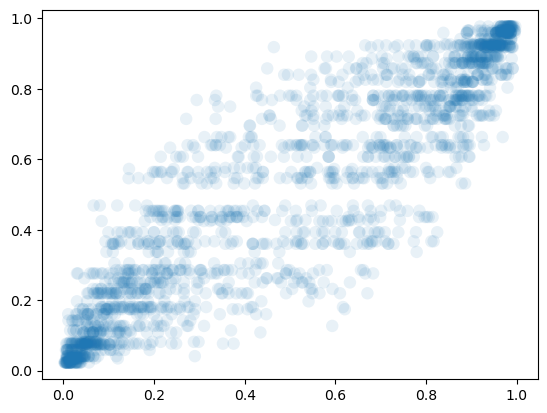

In [73]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_pos_partsamples3'], s=80,alpha=0.1, edgecolor='none')

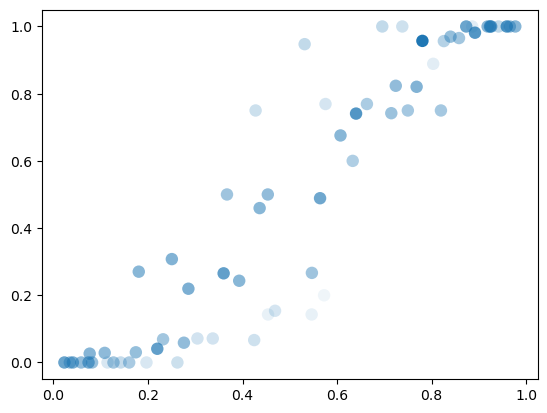

In [75]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_partsamples3",
    "partsamples_arr_3_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [76]:
trials_df['LPO_pos_partsample3'] = logit(trials_df['post_prob_pos_partsamples3'])

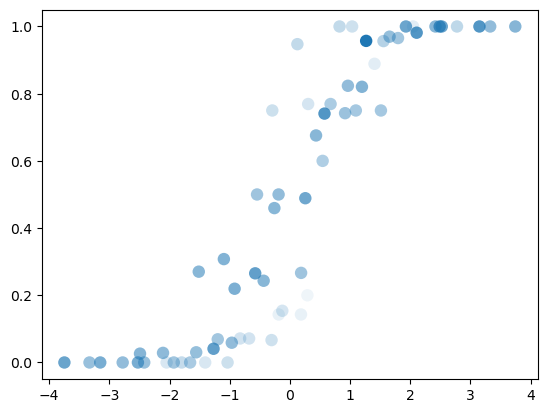

In [77]:
p_RgX, L_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "LPO_pos_partsample3",
    "partsamples_arr_3_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(L_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [ ]:
def obj_function(cutpair, dist_neg, dist_pos, p_Y):
    return -compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, [-cutpair[1], -cutpair[0], 0, cutpair[0], cutpair[1]])

norm_neg = norm(loc=mean_neg, scale=std)
norm_pos = norm(loc=mean_pos, scale=std)

from scipy.optimize import minimize
result = minimize(obj_function, x0=[20, 40], args=(norm_neg, norm_pos, np.array([[0.5, 0.5]])), bounds=[(0, 89), (0, 89)])
cutpair = result.x
cuts2 = [-cutpair[1], -cutpair[0], 0, cutpair[0], cutpair[1]]
cuts2

[-39.65786978033183,
 -17.845011103563966,
 0,
 17.845011103563966,
 39.65786978033183]

In [79]:
mapper = globals().get("map_to_paritition", map_to_partition)

trials_df["part6samples_arr"] = trials_df["samples_arr"].apply(
    lambda arr: mapper(np.asarray(arr), cuts2)
)

trials_df[["samples_arr", "part6samples_arr"]].head()

,samples_arr,part6samples_arr
0,"[61.0, -38.0, 81.0, 7.0, -37.0, 28.0, 20.0, 19.0]","[5, 1, 5, 3, 1, 4, 4, 4]"
1,"[-67.0, -35.0, -8.0, -34.0, -61.0, 6.0, -29.0,...","[0, 1, 2, 1, 0, 3, 1, 2, 1, 3, 1, 3]"
2,"[23.0, -25.0, -17.0, -25.0, 5.0, 1.0, -5.0, -2...","[4, 1, 2, 1, 3, 3, 2, 1, 0, 4, 1, 3]"
3,"[-1.0, 67.0, -14.0, 0.0, 9.0, -10.0, 50.0, -32...","[2, 5, 2, 3, 3, 2, 5, 1, 3, 5, 1, 4]"
4,"[56.0, 5.0, 48.0, 47.0]","[5, 3, 5, 5]"


In [80]:
trials_df["part6samples_arr_3"] = trials_df["part6samples_arr"].apply(
    lambda x: np.asarray(x)[-3:] if isinstance(x, (list, np.ndarray)) and len(x) >= 3 else np.nan
)
trials_df[["part6samples_arr", "part6samples_arr_3"]].head()

,part6samples_arr,part6samples_arr_3
0,"[5, 1, 5, 3, 1, 4, 4, 4]","[4, 4, 4]"
1,"[0, 1, 2, 1, 0, 3, 1, 2, 1, 3, 1, 3]","[3, 1, 3]"
2,"[4, 1, 2, 1, 3, 3, 2, 1, 0, 4, 1, 3]","[4, 1, 3]"
3,"[2, 5, 2, 3, 3, 2, 5, 1, 3, 5, 1, 4]","[5, 1, 4]"
4,"[5, 3, 5, 5]","[3, 5, 5]"


In [81]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos_part6samples3"] = trials_df.apply(
    lambda row: float(
        P_source_g_partsamples(
            np.asarray(row["part6samples_arr_3"], dtype=int),
            mean_neg,
            mean_pos,
            std,
            cuts2,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    if isinstance(row["part6samples_arr_3"], (list, np.ndarray)) else np.nan),
    axis=1,
)

trials_df[["post_prob_pos", "post_prob_pos_part6samples3"]].head()

,post_prob_pos,post_prob_pos_part6samples3
0,0.901507,0.932910
1,0.214954,0.419431
2,0.294163,0.544104
3,0.891987,0.820550
4,0.982251,0.980232


In [82]:
trials_df["part6samples_arr_3_enc"] = trials_df["part6samples_arr_3"].apply(
    lambda arr: int(np.sum(10**np.arange(len(arr)-1,-1,-1) * np.asarray(arr))) if isinstance(arr, (list, np.ndarray)) else np.nan
)
trials_df[["part6samples_arr_3", "part6samples_arr_3_enc"]].head()

,part6samples_arr_3,part6samples_arr_3_enc
0,"[4, 4, 4]",444.0
1,"[3, 1, 3]",313.0
2,"[4, 1, 3]",413.0
3,"[5, 1, 4]",514.0
4,"[3, 5, 5]",355.0


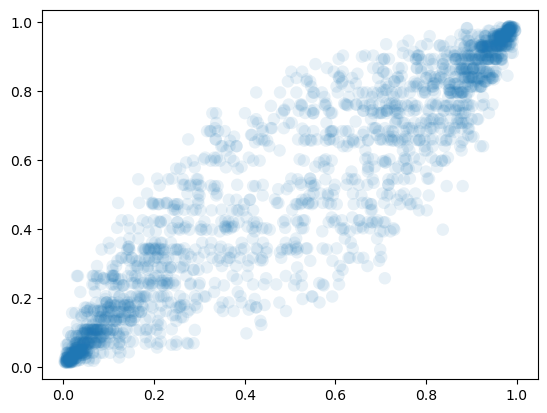

In [83]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_pos_part6samples3'], s=80,alpha=0.1, edgecolor='none')

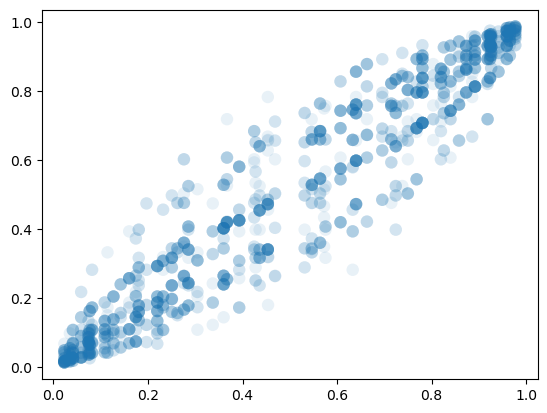

In [84]:
plt.scatter(trials_df['post_prob_pos_partsamples3'], trials_df['post_prob_pos_part6samples3'], s=80,alpha=0.1, edgecolor='none')

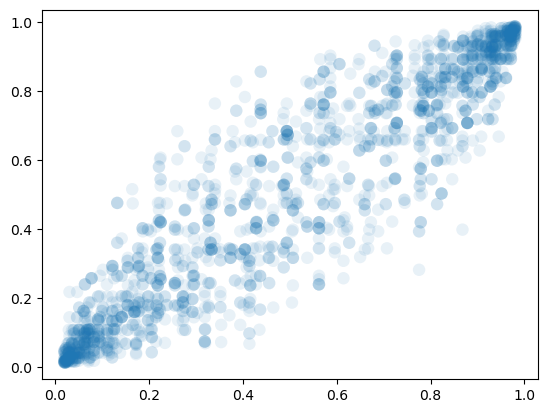

In [85]:
plt.scatter(trials_df['post_prob_pos_partsamples4'], trials_df['post_prob_pos_part6samples3'], s=80,alpha=0.1, edgecolor='none')

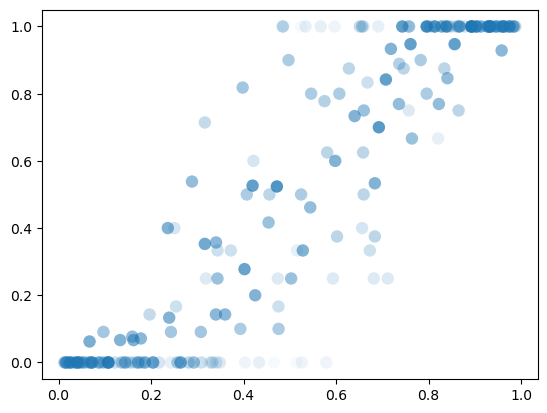

In [86]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_part6samples3",
    "part6samples_arr_3_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

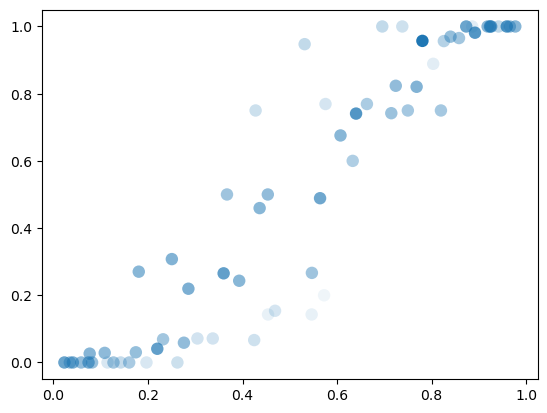

In [87]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_partsamples3",
    "partsamples_arr_3_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [88]:
cuts3 = [0]

mapper = globals().get("map_to_paritition", map_to_partition)

trials_df["part2samples_arr"] = trials_df["samples_arr"].apply(
    lambda arr: mapper(np.asarray(arr), cuts3)
)

trials_df[["samples_arr", "part2samples_arr"]].head()

,samples_arr,part2samples_arr
0,"[61.0, -38.0, 81.0, 7.0, -37.0, 28.0, 20.0, 19.0]","[1, 0, 1, 1, 0, 1, 1, 1]"
1,"[-67.0, -35.0, -8.0, -34.0, -61.0, 6.0, -29.0,...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]"
2,"[23.0, -25.0, -17.0, -25.0, 5.0, 1.0, -5.0, -2...","[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]"
3,"[-1.0, 67.0, -14.0, 0.0, 9.0, -10.0, 50.0, -32...","[0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]"
4,"[56.0, 5.0, 48.0, 47.0]","[1, 1, 1, 1]"


In [90]:
trials_df["part2samples_arr_7"] = trials_df["part2samples_arr"].apply(
    lambda x: np.asarray(x)[-7:] if isinstance(x, (list, np.ndarray)) and len(x) >= 7 else np.nan
)
trials_df[["part2samples_arr", "part2samples_arr_7"]].head()

,part2samples_arr,part2samples_arr_7
0,"[1, 0, 1, 1, 0, 1, 1, 1]","[0, 1, 1, 0, 1, 1, 1]"
1,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]","[1, 0, 0, 0, 1, 0, 1]"
2,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]","[1, 0, 0, 0, 1, 0, 1]"
3,"[0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]","[0, 1, 0, 1, 1, 0, 1]"
4,"[1, 1, 1, 1]",NaN


In [92]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos_part2samples7"] = trials_df.apply(
    lambda row: float(
        P_source_g_partsamples(
            np.asarray(row["part2samples_arr_7"], dtype=int),
            mean_neg,
            mean_pos,
            std,
            cuts3,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    if isinstance(row["part2samples_arr_7"], (list, np.ndarray)) else np.nan),
    axis=1,
)

trials_df[["post_prob_pos", "post_prob_pos_part2samples7"]].head()

,post_prob_pos,post_prob_pos_part2samples7
0,0.901507,0.906420
1,0.214954,0.468497
2,0.294163,0.468497
3,0.891987,0.723215
4,0.982251,NaN


In [93]:
trials_df["part2samples_arr_7_enc"] = trials_df["part2samples_arr_7"].apply(
    lambda arr: int(np.sum(10**np.arange(len(arr)-1,-1,-1) * np.asarray(arr))) if isinstance(arr, (list, np.ndarray)) else np.nan
)
trials_df[["part2samples_arr_7", "part2samples_arr_7_enc"]].head()

,part2samples_arr_7,part2samples_arr_7_enc
0,"[0, 1, 1, 0, 1, 1, 1]",110111.0
1,"[1, 0, 0, 0, 1, 0, 1]",1000101.0
2,"[1, 0, 0, 0, 1, 0, 1]",1000101.0
3,"[0, 1, 0, 1, 1, 0, 1]",101101.0
4,NaN,NaN


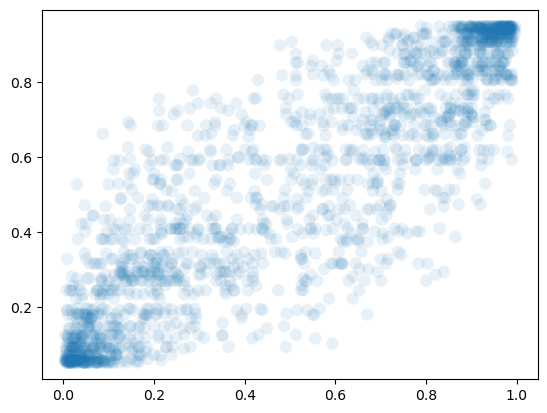

In [94]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_pos_part2samples7'], s=80,alpha=0.1, edgecolor='none')

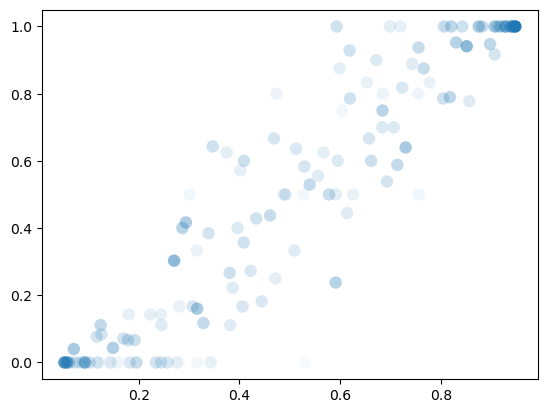

In [146]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_part2samples7",
    "part2samples_arr_7_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

(array([36., 50., 25.,  9.,  5.,  1.,  0.,  1.,  0.,  1.]),
 array([ 2. ,  8.4, 14.8, 21.2, 27.6, 34. , 40.4, 46.8, 53.2, 59.6, 66. ]),
 <BarContainer object of 10 artists>)

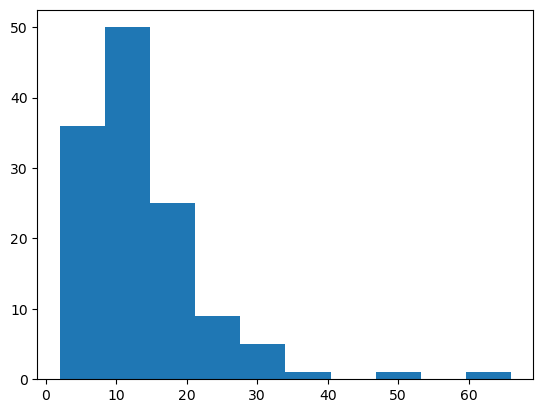

In [148]:
plt.hist(counts)

In [97]:
trials_df["part2samples_arr_9"] = trials_df["part2samples_arr"].apply(
    lambda x: np.asarray(x)[-9:] if isinstance(x, (list, np.ndarray)) and len(x) >= 9 else np.nan
)
trials_df[["part2samples_arr", "part2samples_arr_9"]].head()

,part2samples_arr,part2samples_arr_9
0,"[1, 0, 1, 1, 0, 1, 1, 1]",NaN
1,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]","[0, 0, 1, 0, 0, 0, 1, 0, 1]"
2,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]","[0, 1, 1, 0, 0, 0, 1, 0, 1]"
3,"[0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]","[1, 1, 0, 1, 0, 1, 1, 0, 1]"
4,"[1, 1, 1, 1]",NaN


In [98]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos_part2samples9"] = trials_df.apply(
    lambda row: float(
        P_source_g_partsamples(
            np.asarray(row["part2samples_arr_9"], dtype=int),
            mean_neg,
            mean_pos,
            std,
            cuts3,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    if isinstance(row["part2samples_arr_9"], (list, np.ndarray)) else np.nan),
    axis=1,
)

trials_df[["post_prob_pos", "post_prob_pos_part2samples9"]].head()

,post_prob_pos,post_prob_pos_part2samples9
0,0.901507,NaN
1,0.214954,0.419681
2,0.294163,0.475404
3,0.891987,0.787688
4,0.982251,NaN


In [99]:
trials_df["part2samples_arr_9_enc"] = trials_df["part2samples_arr_9"].apply(
    lambda arr: int(np.sum(10**np.arange(len(arr)-1,-1,-1) * np.asarray(arr))) if isinstance(arr, (list, np.ndarray)) else np.nan
)
trials_df[["part2samples_arr_9", "part2samples_arr_9_enc"]].head()

,part2samples_arr_9,part2samples_arr_9_enc
0,NaN,NaN
1,"[0, 0, 1, 0, 0, 0, 1, 0, 1]",1000101.0
2,"[0, 1, 1, 0, 0, 0, 1, 0, 1]",11000101.0
3,"[1, 1, 0, 1, 0, 1, 1, 0, 1]",110101101.0
4,NaN,NaN


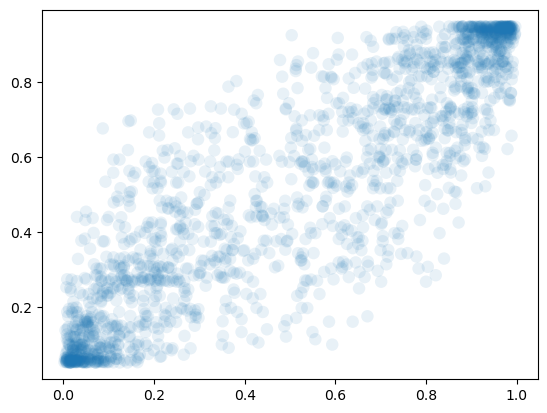

In [100]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_pos_part2samples9'], s=80,alpha=0.1, edgecolor='none')

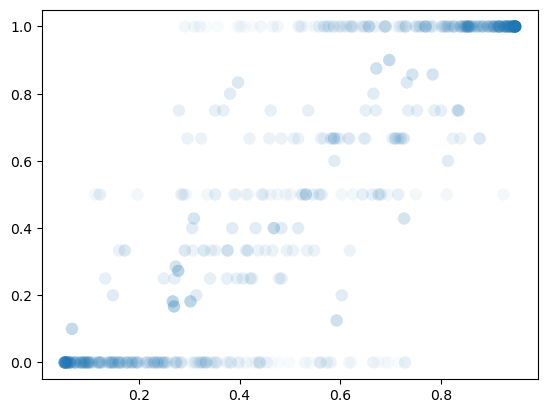

In [101]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_part2samples9",
    "part2samples_arr_9_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [149]:
trials_df["part2samples_arr_5"] = trials_df["part2samples_arr"].apply(
    lambda x: np.asarray(x)[-5:] if isinstance(x, (list, np.ndarray)) and len(x) >= 5 else np.nan
)
trials_df[["part2samples_arr", "part2samples_arr_5"]].head()

,part2samples_arr,part2samples_arr_5
0,"[1, 0, 1, 1, 0, 1, 1, 1]","[1, 0, 1, 1, 1]"
1,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]","[0, 0, 1, 0, 1]"
2,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1]","[0, 0, 1, 0, 1]"
3,"[0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]","[0, 1, 1, 0, 1]"
4,"[1, 1, 1, 1]",NaN


In [150]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos_part2samples5"] = trials_df.apply(
    lambda row: float(
        P_source_g_partsamples(
            np.asarray(row["part2samples_arr_5"], dtype=int),
            mean_neg,
            mean_pos,
            std,
            cuts3,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    if isinstance(row["part2samples_arr_5"], (list, np.ndarray)) else np.nan),
    axis=1,
)

trials_df[["post_prob_pos", "post_prob_pos_part2samples5"]].head()

,post_prob_pos,post_prob_pos_part2samples5
0,0.901507,0.902143
1,0.214954,0.479267
2,0.294163,0.479267
3,0.891987,0.711003
4,0.982251,NaN


In [151]:
trials_df["part2samples_arr_5_enc"] = trials_df["part2samples_arr_5"].apply(
    lambda arr: int(np.sum(10**np.arange(len(arr)-1,-1,-1) * np.asarray(arr))) if isinstance(arr, (list, np.ndarray)) else np.nan
)
trials_df[["part2samples_arr_5", "part2samples_arr_5_enc"]].head()

,part2samples_arr_5,part2samples_arr_5_enc
0,"[1, 0, 1, 1, 1]",10111.0
1,"[0, 0, 1, 0, 1]",101.0
2,"[0, 0, 1, 0, 1]",101.0
3,"[0, 1, 1, 0, 1]",1101.0
4,NaN,NaN


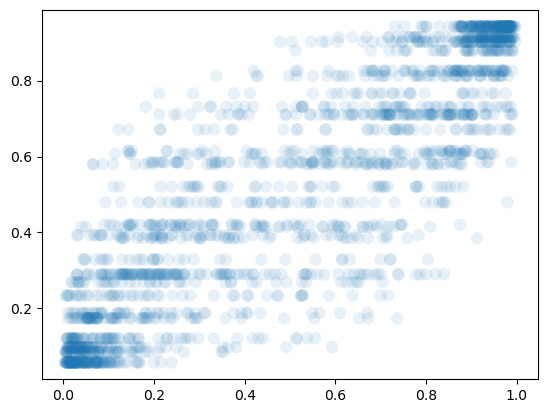

In [152]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_pos_part2samples5'], s=80,alpha=0.1, edgecolor='none')

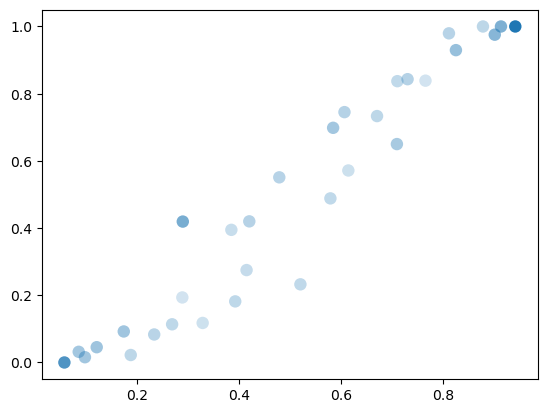

In [153]:
p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
    trials_df,
    "post_prob_pos_part2samples5",
    "part2samples_arr_5_enc",
    block_metadata_df=None,
    block_conditions=None,
    response_col="response",
    block_id_col="block_id",
    sort=True,
    return_counts=True,
)
plt.scatter(p_YgX, p_RgX, s=80, alpha=counts / counts.max(), edgecolor='none')

In [160]:
trials_df['n_presented_samples'].value_counts()

n_presented_samples
12    1503
10      58
8       54
3       53
9       53
4       51
11      51
2       50
7       48
6       44
5       40
Name: count, dtype: int64

In [33]:
bins_opt, bins_1b

(array([-6.0222237 , -4.84924399, -3.67626427, -2.50328456, -1.33030485,
        -0.15732513,  1.01565458,  2.18863429,  3.36161401,  4.53459372,
         5.70757344]),
 array([-3.63852556e+00, -2.91082045e+00, -2.18311534e+00, -1.45541023e+00,
        -7.27705113e-01,  4.44089210e-16,  7.27705113e-01,  1.45541023e+00,
         2.18311534e+00,  2.91082045e+00,  3.63852556e+00]))

In [34]:
np.exp(bins_opt) / (np.exp(bins_opt) + 1), np.exp(bins_1b) / (np.exp(bins_1b) + 1)

(array([0.00241841, 0.0077734 , 0.02469223, 0.07562824, 0.20910894,
        0.46074964, 0.7341253 , 0.89922421, 0.9664831 , 0.98938267,
        0.99669027]),
 array([0.02561757, 0.05162125, 0.10127702, 0.18917032, 0.32569853,
        0.5       , 0.67430147, 0.81082968, 0.89872298, 0.94837875,
        0.97438243]))

In [35]:
P_YgX_2d[:,:,0]

array([[0.0050959 , 0.0050959 , 0.0050959 , 0.0050959 , 0.0050959 ,
        0.0050959 , 0.0050959 , 0.0050959 , 0.0050959 , 0.0050959 ],
       [0.01623282, 0.01623282, 0.01623282, 0.01623282, 0.01623282,
        0.01623282, 0.01623282, 0.01623282, 0.01623282, 0.01623282],
       [0.05016024, 0.05016024, 0.05016024, 0.05016024, 0.05016024,
        0.05016024, 0.05016024, 0.05016024, 0.05016024, 0.05016024],
       [0.14236859, 0.14236859, 0.14236859, 0.14236859, 0.14236859,
        0.14236859, 0.14236859, 0.14236859, 0.14236859, 0.14236859],
       [0.33492929, 0.33492929, 0.33492929, 0.33492929, 0.33492929,
        0.33492929, 0.33492929, 0.33492929, 0.33492929, 0.33492929],
       [0.59743747, 0.59743747, 0.59743747, 0.59743747, 0.59743747,
        0.59743747, 0.59743747, 0.59743747, 0.59743747, 0.59743747],
       [0.81667476, 0.81667476, 0.81667476, 0.81667476, 0.81667476,
        0.81667476, 0.81667476, 0.81667476, 0.81667476, 0.81667476],
       [0.93285366, 0.93285366, 0.9328536

In [36]:
from scipy.special import logit
trials_df['LPO_pos'] = logit(trials_df['post_prob_pos'])
trials_df['LPO_1b_pos'] = logit(trials_df['post_prob_1b_pos'])
trials_df[["block_id", "trial", "LPO_pos", "LPO_1b_pos"]].head()

,block_id,trial,LPO_pos,LPO_1b_pos
0,DCB_S1_B1,1,2.214082,0.768133
1,DCB_S1_B1,2,-1.295317,0.161712
2,DCB_S1_B1,3,-0.875250,0.444709
3,DCB_S1_B1,4,2.111204,1.172414
4,DCB_S1_B1,5,4.013534,1.900119


array([[<Axes: title={'center': 'post_prob_pos'}>]], dtype=object)

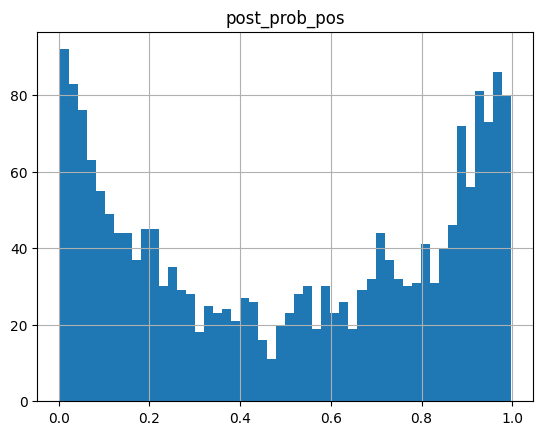

In [37]:
trials_df.hist(column="post_prob_pos", bins=50)

array([[<Axes: title={'center': 'post_prob_1b_pos'}>]], dtype=object)

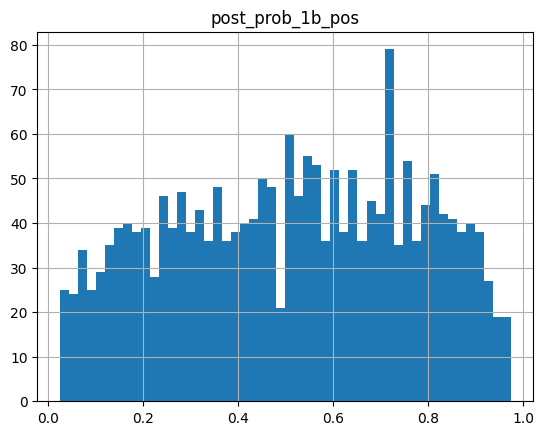

In [38]:
trials_df.hist(column="post_prob_1b_pos", bins=50)

(array([ 1.,  2.,  1.,  4.,  6., 15., 10., 17., 21., 20., 37., 25., 46.,
        43., 48., 52., 54., 60., 66., 77., 77., 64., 61., 61., 68., 53.,
        73., 74., 73., 87., 68., 70., 55., 61., 83., 56., 69., 43., 41.,
        44., 25., 22., 27., 19., 13.,  6.,  3.,  0.,  2.,  2.]),
 array([-6.0222237 , -5.78762776, -5.55303182, -5.31843587, -5.08383993,
        -4.84924399, -4.61464805, -4.3800521 , -4.14545616, -3.91086022,
        -3.67626427, -3.44166833, -3.20707239, -2.97247645, -2.7378805 ,
        -2.50328456, -2.26868862, -2.03409268, -1.79949673, -1.56490079,
        -1.33030485, -1.0957089 , -0.86111296, -0.62651702, -0.39192108,
        -0.15732513,  0.07727081,  0.31186675,  0.5464627 ,  0.78105864,
         1.01565458,  1.25025052,  1.48484647,  1.71944241,  1.95403835,
         2.18863429,  2.42323024,  2.65782618,  2.89242212,  3.12701807,
         3.36161401,  3.59620995,  3.83080589,  4.06540184,  4.29999778,
         4.53459372,  4.76918966,  5.00378561,  5.23838155,

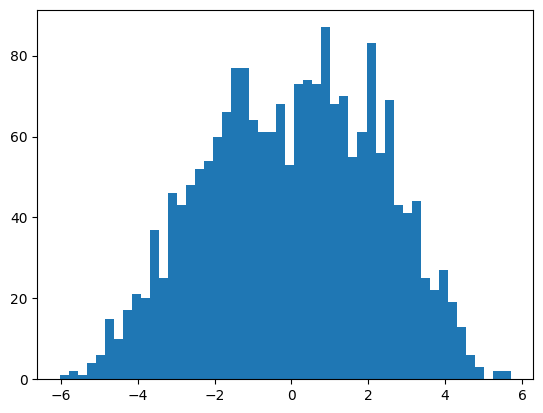

In [39]:
from scipy.special import logit
plt.hist(logit(trials_df["post_prob_pos"]), bins=50)

In [40]:
def P_source_g_samples_alt(LLR_arr,h,L0):
    L = L0
    for ii in range(len(LLR_arr)):
        L = (L + np.log((1-h)/h + np.exp(-L)) - np.log((1-h)/h + np.exp(L))) + LLR_arr[ii]
    p = np.exp(L) / (1+np.exp(L))
    P = np.stack((1-p,p),axis=0).reshape(-1,1)
    return P

<Axes: >

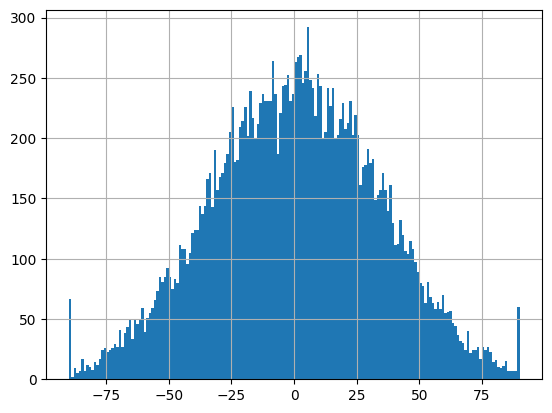

In [41]:
samples_df['stim_location_deg'].hist(bins=np.arange(-90, 91, 1))

In [42]:
samples_df['stim_location_deg'].describe()

count    21349.000000
mean         0.006839
std         33.445009
min        -90.000000
25%        -23.000000
50%          0.000000
75%         23.000000
max         90.000000
Name: stim_location_deg, dtype: float64

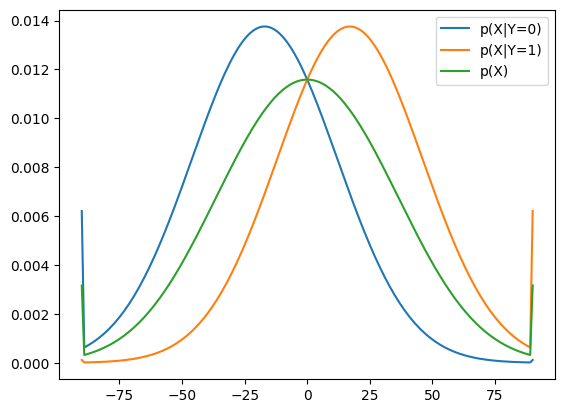

In [43]:
from scipy.stats import norm

mean0, mean1 = -17, 17
std = 29

X = np.arange(-90, 91)
p_XgY0 = np.zeros(181)
p_XgY1 = np.zeros(181)

p_XgY0[0] = norm.cdf(-90.5,loc=mean0,scale=std)
p_XgY1[0] = norm.cdf(-90.5,loc=mean1,scale=std)

p_XgY0[-1] = 1 - norm.cdf(90.5,loc=mean0,scale=std)
p_XgY1[-1] = 1 - norm.cdf(90.5,loc=mean1,scale=std)
for i in range(181):
    p_XgY0[i] += norm.cdf(X[i]+0.5,loc=mean0,scale=std) - norm.cdf(X[i]-0.5,loc=mean0,scale=std)
    p_XgY1[i] += norm.cdf(X[i]+0.5,loc=mean1,scale=std) - norm.cdf(X[i]-0.5,loc=mean1,scale=std)

p_X = 0.5 * p_XgY0 + 0.5 * p_XgY1

import matplotlib.pyplot as plt
plt.plot(X, p_XgY0, label="p(X|Y=0)")
plt.plot(X, p_XgY1, label="p(X|Y=1)")
plt.plot(X, p_X, label="p(X)")
plt.legend()
plt.show()

In [44]:
p_XgY = np.stack((p_XgY0, p_XgY1), axis=1)
p_Y = np.array([[0.5,0.5]])
p_XY = p_XgY * p_Y
p_X = p_XY.sum(axis=1, keepdims=True)
Ixy = np.nansum(p_XY * np.log(p_XY / (p_X * p_Y)))
Ixy

0.14724358622089606

In [45]:
def partition_normal(norm_obj, cuts):
    cuts = np.asarray(cuts)
    cdf_values = norm_obj.cdf(cuts)
    probabilities = np.diff(np.concatenate(([0], cdf_values, [1])))
    return probabilities

def compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, cuts):
    p_XgY0 = partition_normal(dist_neg, cuts)
    p_XgY1 = partition_normal(dist_pos, cuts)
    p_XgY = np.stack((p_XgY0, p_XgY1), axis=1)
    p_XY = p_Y * p_XgY
    p_X = p_XY.sum(axis=1,keepdims=True)
    Ixy = np.nansum(p_XY * np.log(p_XY/(p_X*p_Y)))
    return Ixy

In [46]:
norm_neg = norm(loc=mean0, scale=std)
norm_pos = norm(loc=mean1, scale=std)
cuts = [-25, 0, 25]
partition_normal(norm_neg, cuts), partition_normal(norm_pos, cuts)

(array([0.391327  , 0.32980475, 0.20509829, 0.07376996]),
 array([0.07376996, 0.20509829, 0.32980475, 0.391327  ]))

In [47]:
np.sum(np.stack((partition_normal(norm_neg, cuts), partition_normal(norm_pos, cuts)), axis=1) * np.array([[0.5, 0.5]]),axis=1,keepdims=True)

array([[0.23254848],
       [0.26745152],
       [0.26745152],
       [0.23254848]])

In [48]:
compute_partitioned_Ixy(norm_neg, norm_pos, np.array([[0.5, 0.5]]), cuts)

0.1336369178623429

In [49]:
compute_partitioned_Ixy(norm_neg, norm_pos, np.array([[0.5, 0.5]]), [0])

0.10126594271865075

In [50]:
cuts = [-20,0,20]
compute_partitioned_Ixy(norm_neg, norm_pos, np.array([[0.5, 0.5]]), cuts)

0.13193331749947912

In [51]:
def obj_function(cut, dist_neg, dist_pos, p_Y):
    return -compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, [-cut,0,cut])

from scipy.optimize import minimize_scalar
result = minimize_scalar(obj_function, args=(norm_neg, norm_pos, np.array([[0.5, 0.5]])), bounds=(0, 89), method='bounded')

result

 message: Solution found.
 success: True
  status: 0
     fun: -0.133763340116135
       x: 26.861508114762714
     nit: 10
    nfev: 10

In [52]:
def obj_function(cut, dist_neg, dist_pos, p_Y):
    return -compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, [-cut,cut])

from scipy.optimize import minimize_scalar
result = minimize_scalar(obj_function, args=(norm_neg, norm_pos, np.array([[0.5, 0.5]])), bounds=(0, 89), method='bounded')

result

 message: Solution found.
 success: True
  status: 0
     fun: -0.12464126854895598
       x: 16.87551177836136
     nit: 9
    nfev: 9

In [130]:
def map_to_partition(sample_arr, cuts):
    sample_arr = np.asarray(sample_arr)
    cuts = np.asarray(cuts)
    bin_edges = np.concatenate(([-np.inf], cuts, [np.inf]))
    bin_indices = np.digitize(sample_arr, bin_edges) - 1
    return bin_indices

def P_source_g_partsamples(samples_arr,mean_neg,mean_pos,std,cuts,h,P0,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    partsamples = map_to_partition(samples_arr, cuts)
    Lneg = P_partsamples_g_neg[partsamples]
    Lpos = P_partsamples_g_pos[partsamples]
    L = np.stack((Lneg,Lpos),axis=1).T
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,-window_size:]
    for ii in range(L.shape[1]):
        P = L[:,ii][:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=0,keepdims=True)
    return P

def P_source_g_partsamples_parallel(sample_arrs,mean_neg,mean_pos,std,cuts,h,P0,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    partsamples = map_to_partition(sample_arrs, cuts)
    Lneg = P_partsamples_g_neg[partsamples]
    Lpos = P_partsamples_g_pos[partsamples]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,:,-window_size:]
    for ii in range(L.shape[2]):
        P = L[:,:,ii][:,:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=1,keepdims=True)
    return P.squeeze()

def P_partsamples_g_source_parallel(sample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    partsamples = map_to_partition(sample_arrs, cuts)
    Lneg = P_partsamples_g_neg[partsamples]
    Lpos = P_partsamples_g_pos[partsamples]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    H = H.T # because we are going "backwards" from source to samples
    P = np.ones((L.shape[0],2,1))
    if window_size is not None:
        L = L[:,:,-window_size:]
    # for ii in range(L.shape[2]-1,0,-1):
    #     P = H @ (L[:,:,ii][:,:,np.newaxis] * P)
    for ii in range(1,L.shape[2]):
        P = H @ (L[:,:,ii-1][:,:,np.newaxis] * P)
    P = L[:,:,L.shape[2]-1][:,:,np.newaxis] * P
    return P.squeeze()

def P_partsamples_g_source_parallel_alt(partsample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    P_partsamples_g_neg = partition_normal(P_sample_g_neg, cuts)
    P_partsamples_g_pos = partition_normal(P_sample_g_pos, cuts)
    Lneg = P_partsamples_g_neg[partsample_arrs]
    Lpos = P_partsamples_g_pos[partsample_arrs]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    H = H.T # because we are going "backwards" from source to samples
    P = np.ones((L.shape[0],2,1))
    if window_size is not None:
        L = L[:,:,-window_size:]
    # for ii in range(L.shape[2]-1,0,-1):
    #     P = H @ (L[:,:,ii][:,:,np.newaxis] * P)
    for ii in range(1,L.shape[2]):
        P = H @ (L[:,:,ii-1][:,:,np.newaxis] * P)
    P = L[:,:,L.shape[2]-1][:,:,np.newaxis] * P
    return P.squeeze()

def P_source_g_partsamples_parallel_alt(sample_arrs,mean_neg,mean_pos,std,cuts,h,P0,window_size=None):
    p_XgY = P_partsamples_g_source_parallel(sample_arrs,mean_neg,mean_pos,std,cuts,h,window_size=window_size)
    p_XY = p_XgY * P0.T
    p_YgX = p_XY / p_XY.sum(axis=1,keepdims=True)
    return p_YgX.squeeze()

def compute_partitioned_seq_Ixy(samples_arr, mean_neg, mean_pos, std, cuts, h, P0):
    p_XgY = P_partsamples_g_source_parallel_alt(samples_arr,mean_neg,mean_pos,std,cuts,h,window_size=None)
    p_XY = p_XgY * P0.T
    p_X = p_XY.sum(axis=1, keepdims=True)
    Ixy = np.nansum(p_XY * np.log(p_XY / (p_X * P0.T)))
    return Ixy

In [145]:
from itertools import product
Xset = np.array(list(product(np.arange(4),repeat=12)))
h = 0.08


In [146]:
compute_partitioned_seq_Ixy(Xset, mean_neg, mean_pos, std, cuts, h, P0=np.array([[0.5],[0.5]]))

0.2719999875479893

In [147]:
Xset = np.array(list(product(np.arange(4),repeat=5)))
Xset.shape

(1024, 5)

In [148]:
compute_partitioned_seq_Ixy(Xset, mean_neg, mean_pos, std, cuts, h, P0=np.array([[0.5],[0.5]]))

0.2640364612794406

In [149]:
def obj_function(cut, Xset, mean_neg, mean_pos, std, h, P0=np.array([[0.5],[0.5]])):
    return -compute_partitioned_seq_Ixy(Xset, mean_neg, mean_pos, std, [-cut,0,cut], h, P0)

from scipy.optimize import minimize_scalar
result = minimize_scalar(obj_function, args=(Xset, mean_neg, mean_pos, std, h), bounds=(0, 89), method='bounded')
result

 message: Solution found.
 success: True
  status: 0
     fun: -0.26404079166592787
       x: 27.153346199328258
     nit: 12
    nfev: 12

In [135]:
p_XgY = P_partsamples_g_source_parallel(Xset,mean_neg,mean_pos,std,cuts,h=0.1,window_size=None)

In [125]:
p_XgY

array([[2.69370553e-07, 1.65784659e-06],
       [2.69370553e-07, 1.65784659e-06],
       [2.69370553e-07, 1.65784659e-06],
       ...,
       [2.69370553e-07, 1.65784659e-06],
       [2.69370553e-07, 1.65784659e-06],
       [2.69370553e-07, 1.65784659e-06]])

In [126]:
Xset

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 2],
       ...,
       [3, 3, 3, ..., 3, 3, 1],
       [3, 3, 3, ..., 3, 3, 2],
       [3, 3, 3, ..., 3, 3, 3]])

In [129]:
p_YgX = P_source_g_partsamples_parallel_alt(Xset,mean_neg,mean_pos,std,cuts,h=0.1,P0=np.array([[0.5],[0.5]]),window_size=None)
p_YgX

array([[0.13977177, 0.86022823],
       [0.13977177, 0.86022823],
       [0.13977177, 0.86022823],
       ...,
       [0.13977177, 0.86022823],
       [0.13977177, 0.86022823],
       [0.13977177, 0.86022823]])

In [78]:
len(list(Xset))

16777216

In [71]:
def obj_function(cut, dist_neg, dist_pos, p_Y):
    return -compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, [-cut,0,cut])

from scipy.optimize import minimize_scalar
result = minimize_scalar(obj_function, args=(norm_neg, norm_pos, np.array([[0.5, 0.5]])), bounds=(0, 89), method='bounded')
cut = result.x
cuts = [-cut, 0, cut]
result.fun, cuts

(-0.133763340116135, [-26.861508114762714, 0, 26.861508114762714])

In [ ]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos"] = trials_df.apply(
    lambda row: float(
        P_source_g_samples(
            np.asarray(row["samples_arr"], dtype=float),
            mean_neg,
            mean_pos,
            std,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    ),
    axis=1,
)

In [90]:
sample_arrs = np.stack((trials_df['samples_arr'].iloc[0],trials_df['samples_arr'].iloc[0],trials_df['samples_arr'].iloc[0]), axis=1).T
sample_arrs

array([[ 61., -38.,  81.,   7., -37.,  28.,  20.,  19.],
       [ 61., -38.,  81.,   7., -37.,  28.,  20.,  19.],
       [ 61., -38.,  81.,   7., -37.,  28.,  20.,  19.]])

In [118]:
P_source_g_partsamples_parallel(sample_arrs, mean_neg, mean_pos, std, cuts, h, P0)

array([[0.14698316, 0.85301684],
       [0.14698316, 0.85301684],
       [0.14698316, 0.85301684]])

In [119]:
P_partsamples_g_source_parallel(sample_arrs, mean_neg, mean_pos, std, cuts, h)

array([[1.26156561e-06, 7.32149686e-06],
       [1.26156561e-06, 7.32149686e-06],
       [1.26156561e-06, 7.32149686e-06]])

In [120]:
P_source_g_partsamples_parallel_alt(sample_arrs, mean_neg, mean_pos, std, cuts, h, P0)

array([[0.14698316, 0.85301684],
       [0.14698316, 0.85301684],
       [0.14698316, 0.85301684]])

In [82]:
map_to_partition(np.stack((trials_df['samples_arr'].iloc[0],trials_df['samples_arr'].iloc[0]), axis=1).T, cuts)

array([[3, 0, 3, 2, 0, 3, 2, 2],
       [3, 0, 3, 2, 0, 3, 2, 2]])

In [84]:
P_partsamples_g_pos[map_to_partition(np.stack((trials_df['samples_arr'].iloc[0],trials_df['samples_arr'].iloc[0]), axis=1).T, cuts)].shape

(2, 8)

In [56]:
h = 0.08
P0 = np.array([[0.5], [0.5]])
P_source_g_samples(trials_df['samples_arr'].iloc[0],mean_neg,mean_pos,std,h,P0)

array([[0.09849301],
       [0.90150699]])

In [59]:
trials_df['samples_arr'].iloc[0]

array([ 61., -38.,  81.,   7., -37.,  28.,  20.,  19.])

In [60]:
map_to_partition(trials_df['samples_arr'].iloc[0], cuts)

array([3, 0, 3, 2, 0, 3, 2, 2])

In [62]:
P_partsamples_g_pos = partition_normal(norm(loc=mean_pos, scale=std), cuts)
P_partsamples_g_pos

array([0.07376996, 0.20509829, 0.32980475, 0.391327  ])

In [65]:
Lpos = P_partsamples_g_pos[map_to_partition(trials_df['samples_arr'].iloc[0], cuts)]

In [66]:
P_partsamples_g_neg = partition_normal(norm(loc=mean_neg, scale=std), cuts)
Lneg = P_partsamples_g_neg[map_to_partition(trials_df['samples_arr'].iloc[0], cuts)]

In [69]:
np.stack((Lneg,Lpos),axis=1).T

array([[0.07376996, 0.391327  , 0.07376996, 0.20509829, 0.391327  ,
        0.07376996, 0.20509829, 0.20509829],
       [0.391327  , 0.07376996, 0.391327  , 0.32980475, 0.07376996,
        0.391327  , 0.32980475, 0.32980475]])

In [58]:
cuts = [-25, 0, 25]
P_source_g_partsamples(trials_df['samples_arr'].iloc[0],mean_neg,mean_pos,std,cuts,h,P0)

array([[0.15651006],
       [0.84348994]])

In [57]:
trials_df['post_prob_pos'].iloc[0]

0.9015069944363487

In [70]:
np.array([[0.5, 0.5]]).shape

(1, 2)

In [50]:
np.log(p_XgY1[-1] / p_XgY0[-1])

3.945245272349476

In [25]:
conds = (samples_df['session']==1) & (samples_df['block']==1) & (samples_df['trial']==7)
samples_df.loc[conds, 'stim_location_deg']

72   -22.0
73    49.0
74   -45.0
75     7.0
76   -12.0
77    33.0
78   -25.0
79    19.0
80    12.0
81   -44.0
82   -54.0
83    -9.0
Name: stim_location_deg, dtype: float64

In [35]:
non_whole_stim_values = samples_df.loc[
    samples_df["stim_location_deg"].notna()
    & ~np.isclose(samples_df["stim_location_deg"], np.round(samples_df["stim_location_deg"])),
    "stim_location_deg",
]

non_whole_stim_values.unique()

array([ 89.99, -89.99])

In [26]:
samples_df.loc[samples_df['stim_location_deg']>89, 'stim_location_deg']

466      89.99
584      89.99
983      89.99
1473     89.99
2350     89.99
2714     89.99
2774     89.99
3536     89.99
3601     89.99
3866     89.99
4855     89.99
5184     89.99
6103     89.99
7010     89.99
9715     89.99
9865     89.99
10197    89.99
10397    89.99
10982    89.99
11575    89.99
11594    89.99
12196    89.99
12564    89.99
12993    89.99
13122    89.99
13414    89.99
13834    89.99
14211    89.99
14468    89.99
15547    89.99
15997    89.99
16061    89.99
16552    89.99
17490    89.99
17654    89.99
17891    89.99
17896    89.99
18430    89.99
18539    89.99
19062    89.99
19658    89.99
19730    89.99
19759    89.99
19910    89.99
19912    89.99
19926    89.99
20443    89.99
20866    89.99
21835    89.99
21944    89.99
22584    89.99
22670    89.99
23558    89.99
23607    89.99
23849    89.99
Name: stim_location_deg, dtype: float64

In [27]:
samples_df.loc[samples_df['stim_location_deg']<-89, 'stim_location_deg']

599     -89.99
641     -89.99
649     -89.99
1273    -89.99
1565    -89.99
         ...  
21955   -89.99
22059   -89.99
22816   -89.99
23335   -89.99
23650   -89.99
Name: stim_location_deg, Length: 67, dtype: float64

In [28]:
trials_df

,block_id,subject_folder,participant_id,session_label,session,block,trial,correct_response_dist,response,accuracy,rt_from_go_cue,trial_onset_ptb,fixation_break_count,n_presented_samples,final_sample_location
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1.0,1.0,1.0,1.515773,1.497944e+09,0.0,8,19.0
1,DCB_S1_B1,DCB,DCB,S1,1,1,2,2.0,2.0,1.0,0.007256,1.497944e+09,0.0,12,4.0
2,DCB_S1_B1,DCB,DCB,S1,1,1,3,2.0,1.0,0.0,0.006124,1.497944e+09,0.0,12,11.0
3,DCB_S1_B1,DCB,DCB,S1,1,1,4,1.0,1.0,1.0,0.006226,1.497944e+09,0.0,12,29.0
4,DCB_S1_B1,DCB,DCB,S1,1,1,5,1.0,1.0,1.0,0.006103,1.497944e+09,0.0,4,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000,DCB_S3_B9,DCB,DCB,S3,3,9,72,1.0,2.0,0.0,0.006108,1.498124e+09,0.0,12,-44.0
2001,DCB_S3_B9,DCB,DCB,S3,3,9,73,2.0,1.0,0.0,0.006171,1.498125e+09,0.0,3,41.0
2002,DCB_S3_B9,DCB,DCB,S3,3,9,74,1.0,1.0,1.0,0.006191,1.498125e+09,0.0,12,19.0
2003,DCB_S3_B9,DCB,DCB,S3,3,9,75,1.0,1.0,1.0,0.006103,1.498125e+09,0.0,12,19.0


In [41]:
samples_arr_by_trial = (
    samples_df.sort_values("sample")
    .groupby(["session", "block", "trial"])["stim_location_deg"]
    .apply(lambda s: s.dropna().to_numpy())
)

trials_df["samples_arr"] = pd.MultiIndex.from_frame(
    trials_df[["session", "block", "trial"]]
).map(samples_arr_by_trial)

trials_df[["session", "block", "trial", "n_presented_samples", "samples_arr"]].head()

,session,block,trial,n_presented_samples,samples_arr
0,1,1,1,8,"[61.0, -38.0, 81.0, 7.0, -37.0, 28.0, 20.0, 19.0]"
1,1,1,2,12,"[-67.0, -35.0, -8.0, -34.0, -61.0, 6.0, -29.0,..."
2,1,1,3,12,"[23.0, -25.0, -17.0, -25.0, 5.0, 1.0, -5.0, -2..."
3,1,1,4,12,"[-1.0, 67.0, -14.0, 0.0, 9.0, -10.0, 50.0, -32..."
4,1,1,5,4,"[56.0, 5.0, 48.0, 47.0]"


In [42]:
samples_df[24:36]

,block_id,subject_folder,participant_id,session_label,session,block,trial,sample,stim_location_deg,generative_dist,distribution_switch,sample_onset_from_trial_s
24,DCB_S1_B1,DCB,DCB,S1,1,1,3,1,23.0,1.0,0.0,0.399986
25,DCB_S1_B1,DCB,DCB,S1,1,1,3,2,-25.0,1.0,0.0,0.799969
26,DCB_S1_B1,DCB,DCB,S1,1,1,3,3,-17.0,1.0,0.0,1.199956
27,DCB_S1_B1,DCB,DCB,S1,1,1,3,4,-25.0,1.0,0.0,1.599941
28,DCB_S1_B1,DCB,DCB,S1,1,1,3,5,5.0,1.0,0.0,1.999928
29,DCB_S1_B1,DCB,DCB,S1,1,1,3,6,1.0,1.0,0.0,2.399905
30,DCB_S1_B1,DCB,DCB,S1,1,1,3,7,-5.0,1.0,0.0,2.799891
31,DCB_S1_B1,DCB,DCB,S1,1,1,3,8,-29.0,1.0,0.0,3.199878
32,DCB_S1_B1,DCB,DCB,S1,1,1,3,9,-48.0,1.0,0.0,3.599864
33,DCB_S1_B1,DCB,DCB,S1,1,1,3,10,31.0,1.0,0.0,3.999851


In [34]:
trials_df[["session", "block", "trial", "n_presented_samples", "samples_arr"]][100]

KeyError: 100

In [13]:
np.sum(samples_df['stim_location_deg'] == 0)

263

In [14]:
2**9

512

In [15]:
4**5

1024